## Import libraries and modules

In [1]:
# Import libraries
import os
import json
import re
import datetime
import pandas as pd
import numpy as np
import requests
#import pyvis
import networkx as nx
import seaborn as sns
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
#from pyvis.network import Network
from scipy.cluster.hierarchy import fcluster, linkage, dendrogram

print("Success!")

from dotenv import load_dotenv

load_dotenv()  # loads variables from file .env

# Set the working directory and file paths
input_directory = os.getenv('INPUT_DIRECTORY')
output_directory = os.getenv('OUTPUT_DIRECTORY')
variantscape_directory = os.getenv('VARIANTSCAPE_DIRECTORY')
cleaning_directory = os.getenv('CLEANING_DIRECTORY')
gene_extraction_directory = os.getenv('GENE_EXTRACTION_DIRECTORY')
categorization_directory = os.getenv('CATEGORIZATION_DIRECTORY')
figures_for_publication = os.getenv('FIGURE_DIRECTORY')
LLM_variant_directory = os.getenv('LLM_VARIANT_DIRECTORY')
classifier_directory = os.getenv('CLASSIFIER_DIRECTORY')
variantscape_LLM_coas_directory = os.getenv('VARIANTSCAPE_LLM_COAS_DIRECTORY')
updated_files_directory = os.getenv('UPDATED_FILES_DIRECTORY')

print("Current directory:", os.getcwd())

Success!
Current directory: /Users/andreiblindu/Desktop/Idiap/code/Variantscape/notebooks/07_figure creation


In [2]:
# Load datasets

#### In input directory
oncomine_genes = pd.read_csv("../05_LLM_variant_extraction/oncomine_ngs_panel.csv", header=None)
ESCAT_genes = pd.read_csv("../06_coassociation_and_network_analysis/ESCAT_pc_genes.csv", header=None)
ESCAT_genes.rename(columns={ESCAT_genes.columns[0]: "ESCAT_genes"}, inplace=True)

#### Set directory with updated files
os.chdir(updated_files_directory)

# Load the variant dataset (v3) and metadata mapping
variant_analysis_df = pd.read_csv("cleaned_df_v4.csv", low_memory=False)
metadata_mapping = pd.read_csv("metadata_mapping.csv", low_memory=False)

# Check the lengths and columns of datasets
len_variant_analysis_df_rows, len_variant_analysis_df_cols = variant_analysis_df.shape
len_oncomine_genes_rows, len_oncomine_genes_cols = oncomine_genes.shape
len_ESCAT_genes_rows, len_ESCAT_genes_cols = ESCAT_genes.shape
len_metadata_mapping_rows, len_metadata_mapping_cols = metadata_mapping.shape

# Validate that the number of columns in variant_analysis_df matches the number of entries in metadata_mapping
if len_variant_analysis_df_cols == len_metadata_mapping_cols:
    print("The number of columns in variant_analysis_df matches the number of metadata entries.")
else:
    print(f"Warning: The number of columns in variant_analysis_df ({len_variant_analysis_df_cols}) does not match the number of metadata entries ({len_metadata_mapping_cols}).")
print("\nSuccess!")
print(f"\nMerged variant dataset: {len_variant_analysis_df_rows:,} rows, {len_variant_analysis_df_cols:,} columns")
print(f"Number of oncomine genes: {len_oncomine_genes_rows:,} rows, {len_oncomine_genes_cols:,} columns")
print(f"Number of ESCAT genes: {len_ESCAT_genes_rows:,} rows, {len_ESCAT_genes_cols:,} columns")
print("\n")
print(ESCAT_genes)

# Validate that the column names in variant_analysis_df correspond to metadata mapping
# Convert metadata_mapping (which is a row) into a dictionary for comparison
metadata_dict = metadata_mapping.iloc[0].to_dict()
missing_metadata = [col for col in variant_analysis_df.columns if col not in metadata_dict]
if not missing_metadata:
    print("\nAll columns in variant_analysis_df have corresponding metadata.")
else:
    print(f"Warning: The following columns in variant_analysis_df do not have corresponding metadata: {missing_metadata}")

# Subdataset 
coas_variant_df = variant_analysis_df.copy()
print(f"Total rows in coas_variant_df: {len(coas_variant_df):,}")
print(f"Total cols in coas_variant_df: {len(coas_variant_df.columns):,}")

# Create the metadata dictionary
print(f"Total cols in metadata mapping: {len(metadata_mapping.columns):,}")

# Calculate the total sum for each column (excluding non-numeric columns like 'PaperId')
total_sum_per_column = coas_variant_df.iloc[:, 5:].sum()
zero_sum_columns = total_sum_per_column[total_sum_per_column == 0]
if zero_sum_columns.empty:
    print("All columns have non-zero totals!")
else:
    print("Columns with a total sum of zero (no associations):")
    print(zero_sum_columns)


Success!

Merged variant dataset: 7,423 rows, 13,890 columns
Number of oncomine genes: 161 rows, 1 columns
Number of ESCAT genes: 6 rows, 1 columns


  ESCAT_genes
0         ATM
1       BRCA1
2       BRCA2
3       CHEK2
4       PALB2
5        PTEN

All columns in variant_analysis_df have corresponding metadata.
Total rows in coas_variant_df: 7,423
Total cols in coas_variant_df: 13,890
Total cols in metadata mapping: 13,892
Columns with a total sum of zero (no associations):
2,4-pyrimidinediamine                             0.0
3-Dimensional Conformal Radiation Therapy         0.0
4'-(9-acridinylamino)methanesulfon-m-anisidide    0.0
5-Fluorouracil/Salicylic Acid Topical Solution    0.0
9F7-F11                                           0.0
                                                 ... 
17370_Treatment                                   0.0
6534_Treatment                                    0.0
astroblastoma                                     0.0
histiocytic sarcoma               

## Figure 3

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_2915/4114639449.py:4: DtypeWarning: Columns (0: CoFoS) have mixed types. Specify dtype option on import or set low_memory=False.
  NER_gene_list = pd.read_csv("cleaned_BioBERT_data.csv") #pd.read_csv("../03_gene_extraction/cleaned_BioBERT_data.csv")


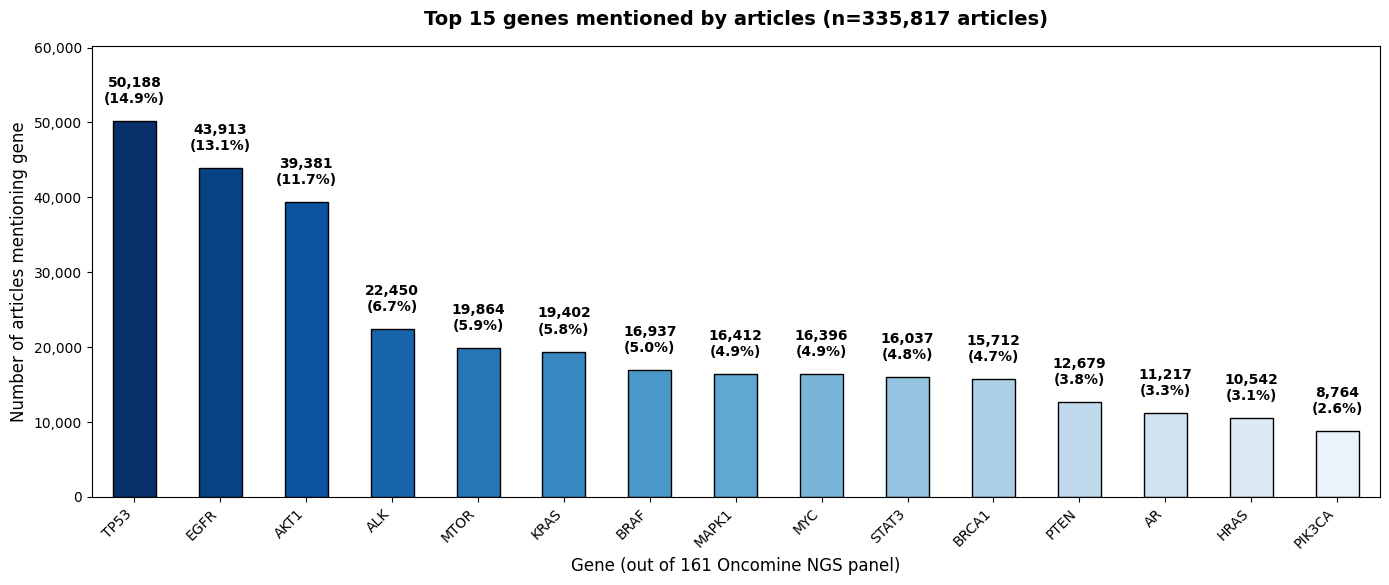

In [ ]:
# Bar chart for ranking of summed relevant columns
oncomine_df = pd.read_csv("../../notebooks/05_LLM_variant_extraction/oncomine_ngs_panel.csv", header=None)
os.chdir(updated_files_directory)
NER_gene_list = pd.read_csv("cleaned_BioBERT_data.csv") #pd.read_csv("../03_gene_extraction/cleaned_BioBERT_data.csv")

# Andrei
'''genes = pd.read_csv('../../notebooks/03_gene_extraction/genes_CIVIC.csv')
mapping = genes.assign(**{'Gene ID': genes['Gene ID'].astype(str)}) \
               .set_index('Gene ID')['Gene Name'] \
               .to_dict()
NER_gene_list = NER_gene_list.rename(columns=mapping)'''
#########

relevant_columns = oncomine_df.iloc[:, 0].tolist()
relevant_columns = [r for r in relevant_columns if r in NER_gene_list.columns]  # Andrei

column_sums = NER_gene_list[relevant_columns].sum().sort_values(ascending=False)
column_sums_formatted = column_sums.apply(lambda x: f"{x:,.0f}")
total_mentions = NER_gene_list['Sum_Gene_Mentions'].sum()
average_mentions = NER_gene_list['Sum_Gene_Mentions'].mean()
mentions_distribution = NER_gene_list['Sum_Gene_Mentions'].value_counts().sort_index()
mentions_distribution_formatted = mentions_distribution.apply(lambda x: f"{x:,}")


fig, ax = plt.subplots(figsize=(14, 7))
top_genes = column_sums.sort_values(ascending=False).head(15)
total_articles = len(NER_gene_list)
percentages = (top_genes / total_articles) * 100
average_mentions = column_sums.sum() / total_articles 
colors = [plt.cm.Blues(1 - (i / len(top_genes))) for i in range(len(top_genes))]

bars = top_genes.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, top_genes.max() * 1.2) 
for bar, value, percent in zip(bars.patches, top_genes, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_height() + (top_genes.max() * 0.04), 
        f"{int(value):,}\n({percent:.1f}%)", 
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='black'
    )

ax.set_title(f'Top 15 genes mentioned by articles (n={total_articles:,.0f} articles)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of articles mentioning gene', fontsize=12)
ax.set_xlabel('Gene (out of 161 Oncomine NGS panel)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout(rect=[0, 0.05, 1, 0.9])
figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_3.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_3.svg", bbox_inches='tight')
plt.show()

## Figure 4

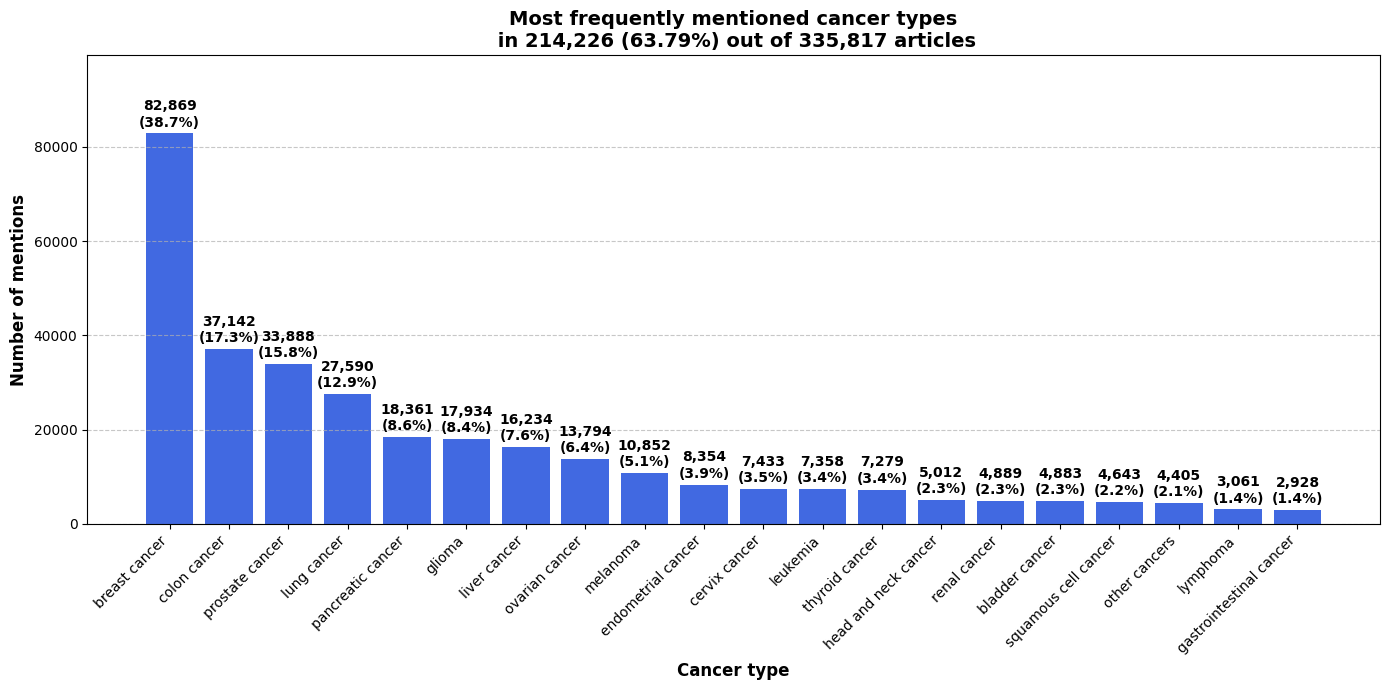

In [ ]:
# Most frequently mentioned cancer types

total_articles_with_specific_cancer_types = 199726 + 14500
total_articles = len(NER_gene_list)
file_path = '../../file_merging/Updated/cancer_category_occurrences_with_percentages.csv' # output_directory + "/cancer_category_occurrences_with_percentages.csv"
df_cancer_occurrences = pd.read_csv(file_path)
top_20_cancers = df_cancer_occurrences.nlargest(20, "count")
colors = ["royalblue" for _ in top_20_cancers["final_parent"]]
max_y_value = top_20_cancers["count"].max()
plt_ylim = max_y_value * 1.2
percentage_specific_cancer_articles = (total_articles_with_specific_cancer_types / total_articles) * 100
plt.figure(figsize=(14, 7))

bars = plt.bar(top_20_cancers["final_parent"], top_20_cancers["count"], color=colors)
plt.xlabel("Cancer type", fontsize=12, fontweight="bold")
plt.ylabel("Number of mentions", fontsize=12, fontweight="bold")
top_20_cancers["percentage"] = (top_20_cancers["count"] / total_articles_with_specific_cancer_types) * 100
plt.title(f"Most frequently mentioned cancer types\n in {total_articles_with_specific_cancer_types:,} "
          f"({percentage_specific_cancer_articles:.2f}%) out of {total_articles:,} articles", 
          fontsize=14, fontweight='bold')

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.ylim(0, plt_ylim)
plt.grid(axis="y", linestyle="--", alpha=0.7)
for bar, value, percentage in zip(bars, top_20_cancers["count"], top_20_cancers["percentage"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + (max_y_value * 0.01), 
        f"{int(value):,}\n({percentage:.1f}%)", 
        ha="center", va="bottom", fontsize=10, fontweight='bold'
    )
    
plt.tight_layout()
figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_4.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_4.svg", bbox_inches='tight')
plt.show()

## Figure 5

In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

csv_file_path = '../../file_merging/Updated/full_df_with_umap_for_scatter_plot.csv'
figure_df = pd.read_csv(csv_file_path)
print(f"Loaded DataFrame with {len(figure_df)} rows from {csv_file_path}")

figure_df["Study_design_clean"] = figure_df["Study_design"].replace({"Behavioral study": "Other", "undefined": "Other"})
scale_factor = 2.5
colorpalette = px.colors.qualitative.Plotly
Study_Type_plot = px.scatter(
    figure_df,
    x="UMAP_1",
    y="UMAP_2",
    color="Study_design_clean",
    hover_data={"PaperTitle": True}, #{"PaperTitle": True, "PubYear": True}, Andrei: removed PubYera
    title=f"Study designs based on abstract similarity (n={len(figure_df)+2:,} articles)",
    labels={"UMAP_1": "UMAP_1", "UMAP_2": "UMAP_2", "Study_design_clean": "Study design"},
    template="plotly_white",
    opacity=0.7,
    color_discrete_sequence=colorpalette
)

Study_Type_plot.update_layout(
    width=int(800 * scale_factor),
    height=int(400 * scale_factor),
    font=dict(size=int(12 * scale_factor)),
    title_font=dict(size=int(16 * scale_factor)),
    legend=dict(title="Study design", font=dict(size=int(10 * scale_factor))),
    hoverlabel=dict(font_size=int(12 * scale_factor), font_family="Arial", bgcolor="white", bordercolor="black", align="left"),
    hovermode="closest"
)

for trace in Study_Type_plot.data:
    if 'marker' in trace:
        trace.marker.size = int(2)
unique_study_types = figure_df["Study_design_clean"].unique()
legend_markers = []
for i, study_type in enumerate(unique_study_types):
    legend_markers.append(go.Scatter(
        x=[None], y=[None],
        mode="markers",
        marker=dict(size=15, color=colorpalette[i % len(colorpalette)], line=dict(width=2, color="black")),
        name=study_type,
        legendgroup="Study design",
        showlegend=True
    ))

for trace in Study_Type_plot.data:
    trace.showlegend = False
for marker in legend_markers:
    Study_Type_plot.add_trace(marker)
html_file_path = "Interactive_scatter_plot_study_design_type_plot.html"

figures_dir = '../../final_figures'
Study_Type_plot.write_html(f'{figures_dir}/Figure_5.html')

print("Open the saved HTML file to see the improved visualization with restored colors.")
print(f"Saved figure: {html_file_path}")

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_4386/908456815.py:6: DtypeWarning: Columns (0: Study Type) have mixed types. Specify dtype option on import or set low_memory=False.
  figure_df = pd.read_csv(csv_file_path)


Loaded DataFrame with 214224 rows from ../../file_merging/Updated/full_df_with_umap_for_scatter_plot.csv
Open the saved HTML file to see the improved visualization with restored colors.
Saved figure: Interactive_scatter_plot_study_design_type_plot.html


## Figure 6

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_4004/328953452.py:54: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.05, right=0.99, bottom=0.35, top=0.95)


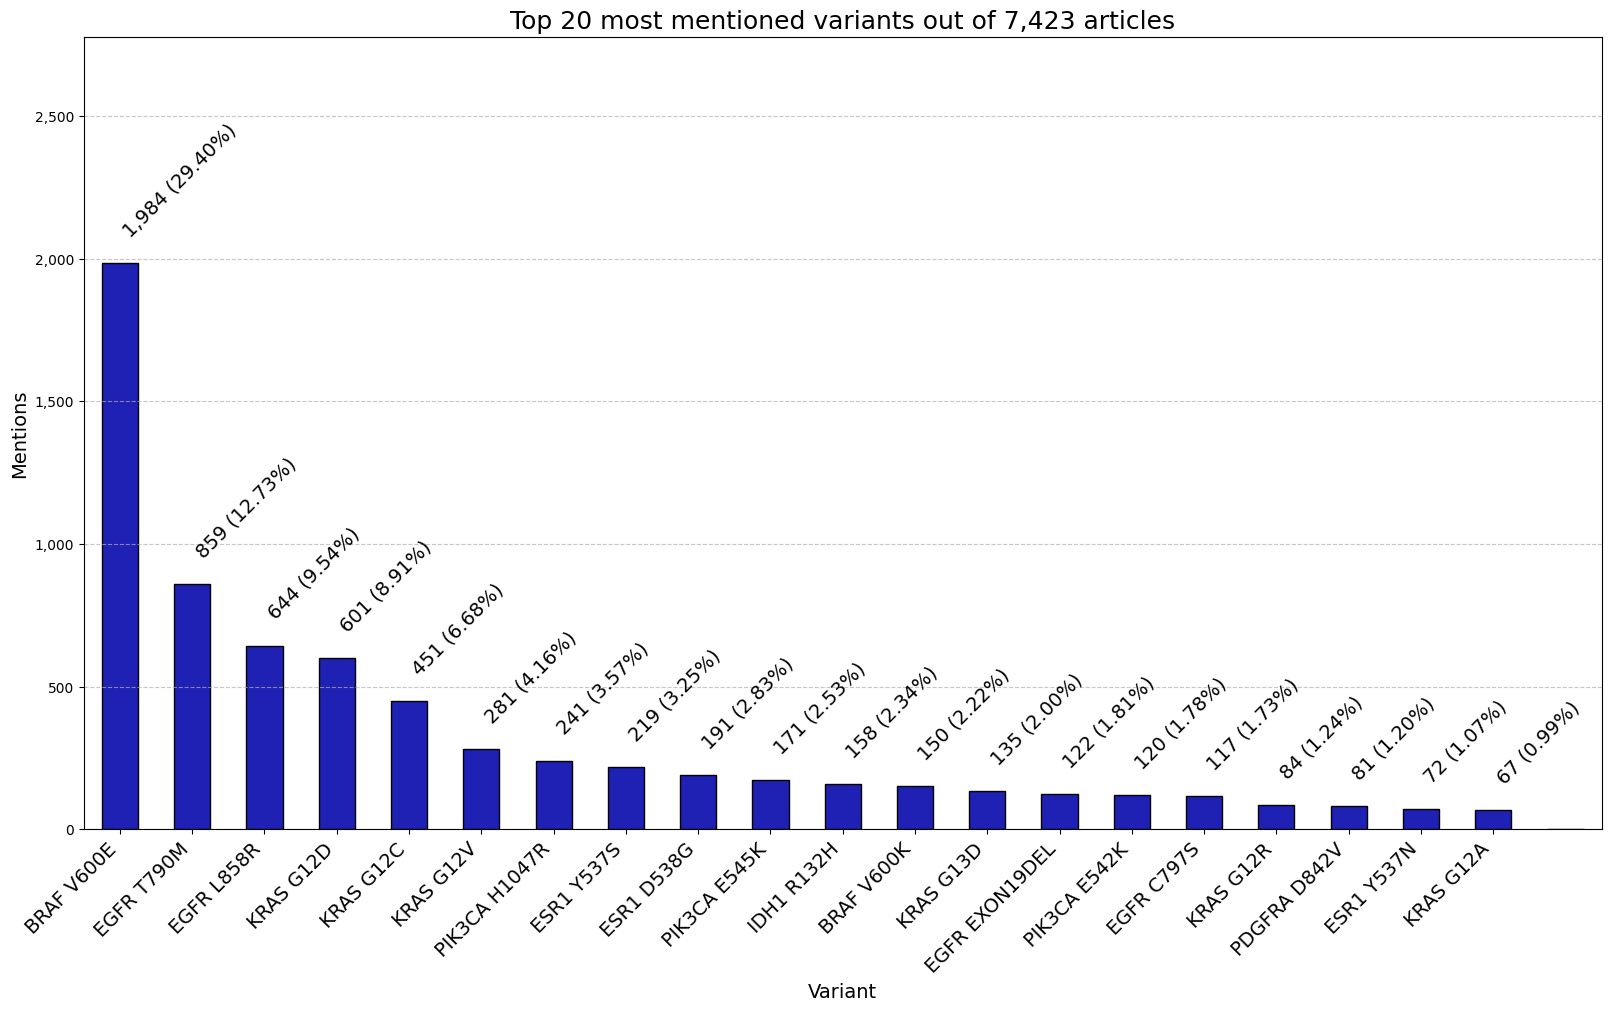

In [ ]:
# Create bar chart
dictionary = metadata_mapping.copy()
coas_variant_df = variant_analysis_df.copy()
total_articles = len(coas_variant_df)

dictionary = dictionary.transpose().reset_index()
dictionary.columns = ["Column_Name", "Category"]

variant_columns = dictionary[dictionary['Category'] == "Variant"]["Column_Name"].tolist()

# Andrei
variant_columns = [v for v in variant_columns if v in coas_variant_df.columns]

variant_df = coas_variant_df[variant_columns]

# Count the mentions for each treatment, cancer, and variant

top_variants = variant_df.sum().sort_values(ascending=False).head(20)

# Calculate percentages
top_variants_percent = (top_variants / total_articles) * 100

def weighted_co_occurrence_matrix(df1, df2, weights, scaling_factor=1.0):
    weights = weights * scaling_factor
    weighted_df1 = df1.mul(weights, axis=0)
    weighted_df2 = df2.mul(weights, axis=0)
    matrix = weighted_df1.T.dot(weighted_df2)
    return pd.DataFrame(matrix, index=df1.columns, columns=df2.columns)
weights = coas_variant_df['Study_weight']

def format_variant_label(label):
    """Convert 'v600e_BRAF' to 'V600E BRAF'."""
    if "_" in label:
        variant, gene = label.split("_")
        return f"{gene.upper()} {variant.upper()}"
    return label.upper()
def plot_and_save_bar_chart(data, title, xlabel, ylabel, file_name, total_articles):
    data_with_padding = data.copy()
    data_with_padding['Invisible Padding'] = 0
    fig, ax = plt.subplots(figsize=(16, 10), constrained_layout=True)
    data_with_padding.plot(kind='bar', color=['#1f20b4'] * len(data) + ['white'], edgecolor='black', ax=ax)
    ax.set_title(f'{title.capitalize()} out of {total_articles:,} articles', fontsize=18)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_ylim(0, data.max() * 1.4)
    plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data.index, rotation=45, ha='right', fontsize=14)
    for i, (label, count) in enumerate(zip(data.index, data.values)):
        percentage = (count / data.sum()) * 100
        plt.text(i, count + (data.max() * 0.04), f"{int(count):,} ({percentage:.2f}%)", 
                 ha='left', va='bottom', fontsize=14, rotation=45)
    plt.subplots_adjust(left=0.05, right=0.99, bottom=0.35, top=0.95)
    plt.savefig(file_name, bbox_inches='tight', pad_inches=0.5, dpi=300)
    plt.show()

figures_dir = '../../final_figures'
top_variants.index = [format_variant_label(v) for v in top_variants.index]

plot_and_save_bar_chart(top_variants, 'Top 20 most mentioned variants', 'Variant', 'Mentions', 
                        os.path.join(figures_dir, 'Figure_6.png'), total_articles)

## Figure 7

In [6]:
import pandas as pd
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load CIVIC dataset
'''final_output_filepath = os.path.join(categorization_directory, "CIVIC_ncit_df_finalparent_treatmentcategory.csv")
CIVIC_ncit_df_finalparent = pd.read_csv(final_output_filepath)
total_rows = len(CIVIC_ncit_df_finalparent)'''

# Terms to exclude
treatments_to_exclude = [
    "chemotherapy", "immunotherapy", "targeted therapy",
    "radiation therapy", "radiation ionizing radiotherapy", "folfox regimen", "iniparib",
    "epidermal growth factor receptor tyrosine kinase inhibitor","tyrosine kinase inhibitor",
    "mitogen-activated protein kinase kinase inhibitor","iodine i-131",
    "anti-vegf monoclonal antibody", "radioactive iodine","egfr tyrosine kinase inhibitor therapy",
    "aromatase inhibitor", "anti-pd-l1 monoclonal antibody", "mrna vaccine", "pd1 inhibitor", 
]
treatments_to_exclude = [t.strip().lower() for t in treatments_to_exclude]

# Load treatment-variant matrix
treatment_variant_matrix = pd.read_csv(
    #os.path.join(variantscape_directory, "treatment_variant_matrix_normalized.csv"),
    "../../file_merging/Updated/treatment_variant_matrix_normalized.csv",
    index_col=0
)
treatment_variant_matrix.columns = treatment_variant_matrix.columns.str.strip().str.lower()
treatment_variant_matrix.index   = treatment_variant_matrix.index.str.strip().str.lower()
treatment_variant_matrix = treatment_variant_matrix[
    ~treatment_variant_matrix.index.isin(treatments_to_exclude)
]

df_consensus = pd.read_csv(
    #os.path.join(variantscape_LLM_coas_directory, "final_variant_treatment_consensus.csv")
    "../../file_merging/Updated/final_variant_treatment_consensus.csv"
)
df_consensus["Variant_Treatment_Pair"] = (
    df_consensus["Variant_Treatment_Pair"]
    .str.lower()
    .str.strip()
)
consensus_dict = dict(
    zip(df_consensus["Variant_Treatment_Pair"], df_consensus["Resolved_Prediction"])
)

# Apply consensus adjustments
adjusted_matrix = treatment_variant_matrix.copy().astype(float)
print("Applying consensus adjustments...")
for treatment, variant in tqdm(
    [(t, v) for t in adjusted_matrix.index for v in adjusted_matrix.columns],
    desc="Consensus Adjustment",
    unit="pair"
):
    key = f"{variant} + {treatment}".strip().lower()
    consensus = consensus_dict.get(key, None)

    if consensus is None or consensus.lower() == "no consensus":
        adjusted_matrix.loc[treatment, variant] = np.nan
    elif consensus.lower() == "resistant":
        adjusted_matrix.loc[treatment, variant] = -abs(adjusted_matrix.loc[treatment, variant])
    # others (sensitive, diagnostic, unrelated) remain positive

# Select strongest positive and negative associations
flat = adjusted_matrix.unstack().dropna()
sorted_flat = flat.sort_values()

top_n = 50  # number of strong positive + negative associations
top_negative = sorted_flat.head(top_n)
top_positive = sorted_flat.tail(top_n)

# Combine and reformat for plotting
focus_pairs = pd.concat([top_positive, top_negative])
focus_df = focus_pairs.reset_index()
focus_df.columns = ["Variant", "Treatment", "Score"]

# Add manually selected treatments (only top 3 variant associations per treatment)
treatments_to_force = [
    "abiraterone", "trastuzumab", "osimertinib",
    "erlotinib", "gefitinib", "crizotinib", "dabrafenib/trametinib regimen", "dabrafenib", "trametinib",
    "alectinib", "ceritinib", "vemurafenib", "encorafenib",
    "pembrolizumab", "nivolumab", "bevacizumab",
]
treatments_to_force = [t.lower().strip() for t in treatments_to_force]

manual_rows = []
for treatment in treatments_to_force:
    if treatment in adjusted_matrix.index:
        variant_scores = adjusted_matrix.loc[treatment].dropna()
        top_variants = variant_scores.reindex(variant_scores.abs().sort_values(ascending=False).index).head(3)
        for variant, score in top_variants.items():
            manual_rows.append({"Treatment": treatment, "Variant": variant, "Score": score})

manual_df = pd.DataFrame(manual_rows)
focus_df = pd.concat([focus_df, manual_df], ignore_index=True).drop_duplicates()

#### Build the focused matrix
top_variants = focus_df["Variant"].unique()
forced_variant_set = set(manual_df["Variant"].unique())
all_variants = list(pd.Index(top_variants).union(forced_variant_set))
all_treatments = list(pd.Index(focus_df["Treatment"].unique()).union(treatments_to_force))
all_treatments = [t for t in all_treatments if t in adjusted_matrix.index]
focus_matrix = adjusted_matrix.loc[all_treatments, all_variants]

# Order rows/columns
col_order = focus_df.groupby("Variant")["Score"].mean().sort_values(ascending=False).index
row_order = focus_df.groupby("Treatment")["Score"].mean().sort_values(ascending=False).index
row_order = pd.Index(row_order.tolist() + [t for t in all_treatments if t not in row_order])
focus_matrix = focus_matrix.loc[row_order, col_order]

'''plt.figure(figsize=(18, 14))
sns.set(style="white")
sns.heatmap(
    focus_matrix,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,  
    linecolor="lightgray", 
    square=False,
    cbar_kws={
        "label": "Association score",
        "shrink": 0.8,
        "orientation": "vertical"
    },
    mask=focus_matrix.isna()
)

# Force display of all Y-axis labels
plt.yticks(
    ticks=np.arange(len(focus_matrix.index)) + 0.5,
    labels=focus_matrix.index,
    fontsize=9,
    rotation=0
)

# Format rest of the plot
cbar = plt.gca().collections[0].colorbar
cbar.ax.set_ylabel("Association score", labelpad=-10)
cbar.ax.yaxis.label.set_rotation(90)

plt.title("Variant–treatment associations", fontsize=18, pad=20)
plt.xlabel("Variants", fontsize=14, labelpad=10)
plt.ylabel("Treatments", fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.tight_layout(rect=[0, 0, 1, 0.97])

#plt.savefig("variant_treatment_heatmap_clean.png", dpi=300)
plt.show()
print("Final treatments shown on Y-axis:")
print(focus_matrix.index.tolist())'''

# Select strongest positive and negative associations
flat = adjusted_matrix.unstack().dropna()
sorted_flat = flat.sort_values()

top_n = 50
top_negative = sorted_flat.head(top_n)
top_positive = sorted_flat.tail(top_n)

# Combine and reformat for plotting
focus_pairs = pd.concat([top_positive, top_negative])
focus_df = focus_pairs.reset_index()
focus_df.columns = ["Variant", "Treatment", "Score"]

# Add manually selected treatments (only top 3 variant associations per treatment)
treatments_to_force = [
    # Targeted therapies
    "trastuzumab", "pertuzumab", "osimertinib", "erlotinib", "gefitinib",
    "crizotinib", "alectinib", "ceritinib", "larotrectinib", "entrectinib",
    "dabrafenib", "trametinib", "vemurafenib", "encorafenib", "binimetinib",
    "imatinib", "sunitinib", "axitinib", "bevacizumab",

    # Immunotherapies
    "pembrolizumab", "nivolumab", "atezolizumab", "durvalumab", "ipilimumab",

    # Hormonal therapies
    "tamoxifen", "letrozole", "anastrozole", "exemestane",
    "abiraterone", "enzalutamide",

    # PARP inhibitors
    "olaparib", "rucaparib", "niraparib", "talazoparib",

    # Chemotherapy
    "cisplatin", "carboplatin", "paclitaxel", "docetaxel","dabrafenib/trametinib","dabrafenib","trametinib"
]
treatments_to_force = [t.lower().strip() for t in treatments_to_force]

manual_rows = []
for treatment in treatments_to_force:
    if treatment in adjusted_matrix.index:
        variant_scores = adjusted_matrix.loc[treatment]
        top_variants = variant_scores.reindex(variant_scores.abs().sort_values(ascending=False).index).head(3)
        for variant in top_variants.index:
            score = variant_scores.get(variant, np.nan)
            manual_rows.append({"Treatment": treatment, "Variant": variant, "Score": score})

manual_df = pd.DataFrame(manual_rows)
focus_df = pd.concat([focus_df, manual_df], ignore_index=True).drop_duplicates()

# Build the focused matrix
# Variants from top-N plus manual associations
top_variants = focus_df["Variant"].unique()
forced_variant_set = set(manual_df["Variant"].unique())
all_variants = list(pd.Index(top_variants).union(forced_variant_set))

# Forced treatments to display
all_treatments = list(pd.Index(focus_df["Treatment"].unique()).union(treatments_to_force))
all_treatments = [t for t in all_treatments if t in adjusted_matrix.index]

focus_matrix = adjusted_matrix.loc[all_treatments, all_variants]
focus_matrix = focus_matrix.dropna(axis=1, how='all')
col_order = focus_df.groupby("Variant")["Score"].mean().sort_values(ascending=False).index
row_order = focus_df.groupby("Treatment")["Score"].mean().sort_values(ascending=False).index
row_order = pd.Index(row_order.tolist() + [t for t in all_treatments if t not in row_order])
col_order = [v for v in col_order if v in focus_matrix.columns] 
focus_matrix = focus_matrix.loc[row_order, col_order]

treatments_to_drop = [
    "naquotinib", "sotrastaurin acetate", "uprosertib", "rindopepimut", 
    "rilotumumab",
]
treatments_to_drop = [t.lower().strip() for t in treatments_to_drop]

# Filter out from focus_matrix
focus_matrix = focus_matrix[~focus_matrix.index.isin(treatments_to_drop)]
row_order = [t for t in row_order if t in focus_matrix.index]
focus_matrix = focus_matrix.loc[row_order]

# Plot heatmap
plt.figure(figsize=(18, 14))
sns.set(style="white")
sns.heatmap(
    focus_matrix,
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="lightgray",
    square=False,
    cbar_kws={
        "label": "Association score",
        "shrink": 0.8,
        "orientation": "vertical"
    }
)

# Y-axis (treatments)
plt.yticks(
    ticks=np.arange(len(focus_matrix.index)) + 0.5,
    labels=focus_matrix.index,
    fontsize=8,
    rotation=0
)

# X-axis (variants)
plt.xticks(
    ticks=np.arange(len(focus_matrix.columns)) + 0.5,
    labels=focus_matrix.columns,
    fontsize=8,
    rotation=45,
    ha="right"
)
cbar = plt.gca().collections[0].colorbar
cbar.ax.set_ylabel("Association score", labelpad=-10)
cbar.ax.yaxis.label.set_rotation(90)
plt.title("Variant–treatment associations", fontsize=18, pad=20)
plt.xlabel("Variants", fontsize=14, labelpad=10)
plt.ylabel("Treatments", fontsize=14, labelpad=10)
plt.tight_layout(rect=[0, 0, 1, 0.97])

figures_dir = '../../final_figures'
#plt.savefig(f"{figures_dir}/Figure_7.png", dpi=300)
#plt.savefig(f"{figures_dir}/Figure_7.svg", dpi=300)

plt.show()

Applying consensus adjustments...


Consensus Adjustment:   1%|          | 62934/7075656 [00:08<16:26, 7109.05pair/s]


KeyboardInterrupt: 

In [5]:
df_consensus = pd.read_csv(
    #os.path.join(variantscape_LLM_coas_directory, "final_variant_treatment_consensus.csv")
    "../../file_merging/Updated/final_variant_treatment_consensus.csv"
)

pd.concat([df_consensus['Resolved_Prediction'].value_counts(),
           df_consensus['Resolved_Prediction'].value_counts(normalize=True)],
           axis=1, keys=['count', 'percentage'])

,count,percentage
Resolved_Prediction,,
Sensitive,4644,0.290959
Unknown,3859,0.241777
Unrelated,3764,0.235825
Resistant,3422,0.214398
Diagnostic,148,0.009273
No consensus,124,0.007769


## Figure 8


Top 5 strongest variant associations per cancer:

--- LUNG CANCER ---
   Variant     Score
t790m_egfr 35.246910
l858r_egfr 27.626841
 g12c_kras  9.157966
v600e_braf  8.129691
 g12d_kras  5.587787

--- BREAST CANCER ---
      Variant     Score
   y537s_esr1 17.298527
   d538g_esr1 16.109185
h1047r_pik3ca 15.420277
 e545k_pik3ca 11.297660
 e542k_pik3ca  8.851820

--- COLON CANCER ---
   Variant     Score
v600e_braf 46.569767
 g12c_kras 12.598630
 g12d_kras 10.460963
 g12v_kras  8.941030
 g13d_kras  7.412791

--- PROSTATE CANCER ---
 Variant     Score
t878a_ar 17.810976
l702h_ar 17.134146
f876l_ar 13.896341
f877l_ar 12.128049
h875y_ar 12.073171

--- MELANOMA ---
   Variant     Score
v600e_braf 73.682842
v600k_braf 14.710324
 q61r_nras  2.974746
 q61k_nras  2.681357
v600r_braf  2.610795



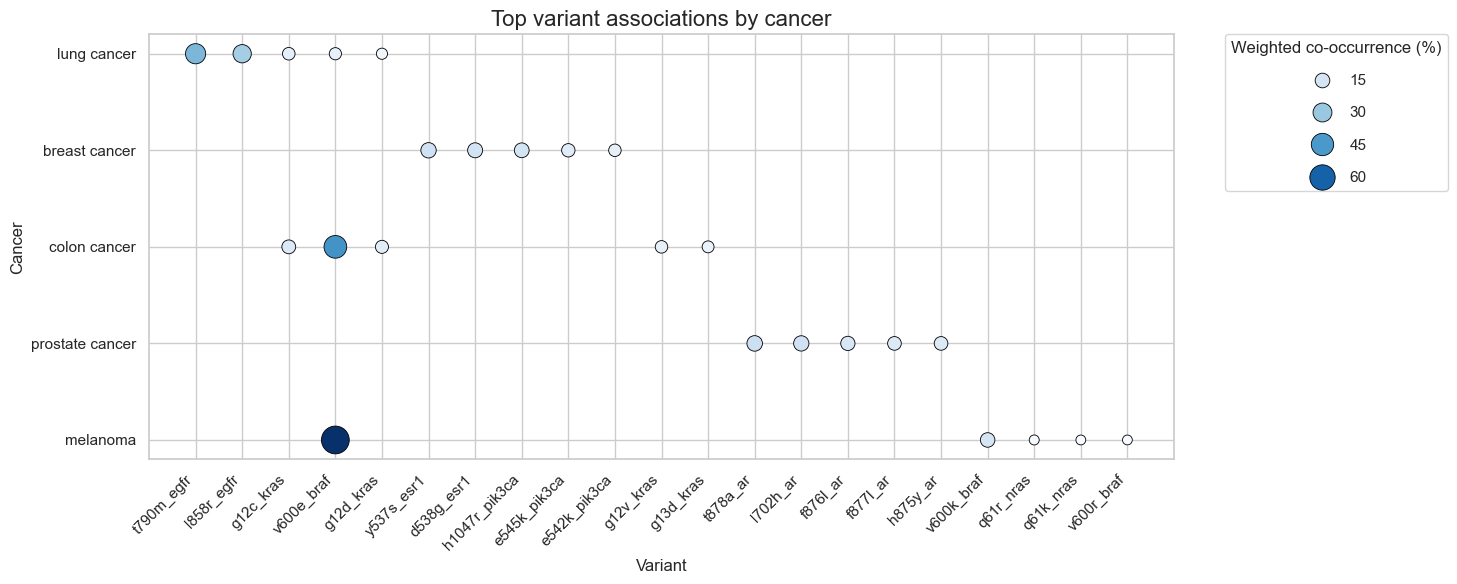

In [ ]:
import pandas as pd
import os

# Load the cancer-variant matrix
matrix_path = os.path.join("../../file_merging/Updated/cancer_variant_matrix_normalized.csv")
cancer_variant_matrix = pd.read_csv(matrix_path, index_col=0)
cancer_variant_matrix.index = cancer_variant_matrix.index.str.strip().str.lower()
cancer_variant_matrix.columns = cancer_variant_matrix.columns.str.strip().str.lower()

# Define cancers and get top 5 strongest variants per cancer (skip "v600")
target_cancers = ['lung cancer', 'breast cancer', 'colon cancer', 'prostate cancer', 'melanoma']
top_rows = []
for cancer in target_cancers:
    row = cancer_variant_matrix.loc[cancer]
    sorted_row = row.reindex(row.abs().sort_values(ascending=False).index)

    picked = 0
    for variant, score in sorted_row.items():
        if variant == "v600" or (variant.startswith("v600_") and variant.count("_") == 1):
            continue
        top_rows.append({
            "Cancer": cancer,
            "Variant": variant,
            "Score": score
        })
        picked += 1
        if picked == 5:
            break
top_df = pd.DataFrame(top_rows)

# Print top 5 table
print("\nTop 5 strongest variant associations per cancer:\n")
for cancer in target_cancers:
    subset = top_df[top_df["Cancer"] == cancer]
    print(f"--- {cancer.upper()} ---")
    print(subset[["Variant", "Score"]].to_string(index=False))
    print()

# Dot plot with bubble legend
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")
dot_plot = sns.scatterplot(
    data=top_df,
    x="Variant",
    y="Cancer",
    size=np.abs(top_df["Score"]),
    hue=top_df["Score"],
    palette="Blues",
    sizes=(50, 400),
    edgecolor="black",
    legend="brief"
)

plt.title("Top variant associations by cancer", fontsize=16)
plt.xlabel("Variant", fontsize=12)
plt.ylabel("Cancer", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
handles, labels = plt.gca().get_legend_handles_labels()
unique = list(dict(zip(labels, handles)).items())
filtered_handles = [h for l, h in unique if l.replace('.', '', 1).isdigit()]
filtered_labels = [l for l in labels if l.replace('.', '', 1).isdigit()]
plt.legend(
    filtered_handles,
    filtered_labels,
    title="Weighted co-occurrence (%)",
    loc='upper left',
    bbox_to_anchor=(1.05, 1),
    borderaxespad=0.,
    labelspacing=1.2,
    frameon=True
)
figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_8.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{figures_dir}/Figure_8.svg", bbox_inches="tight")
plt.show()

## Supplementary figure 1

Success!


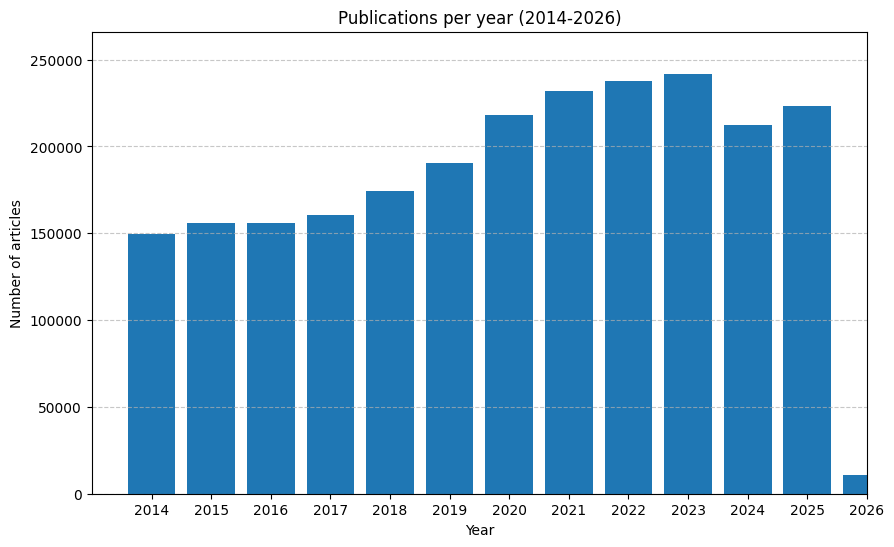

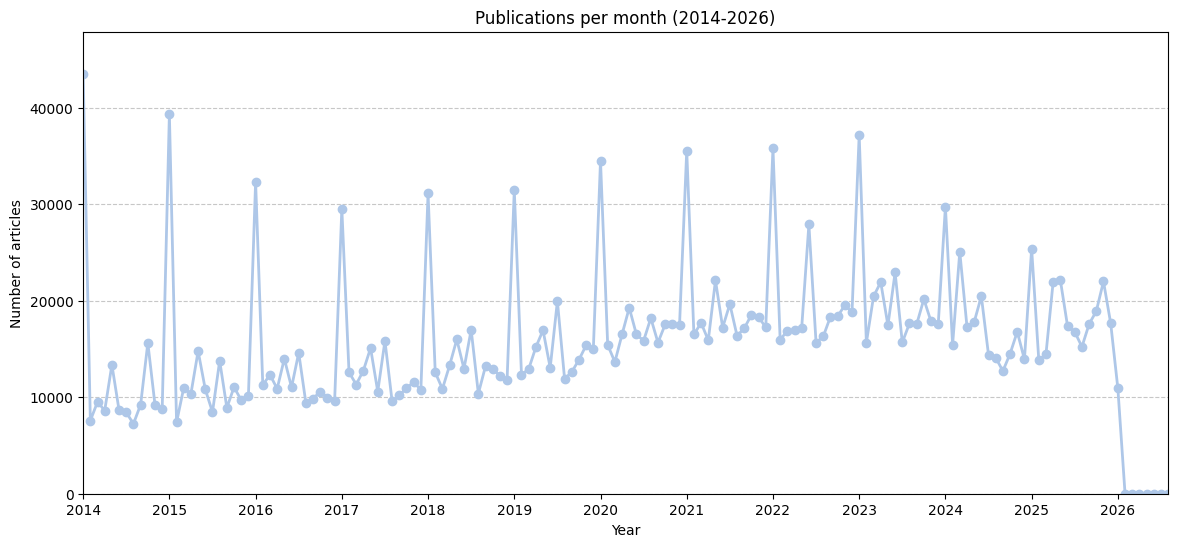

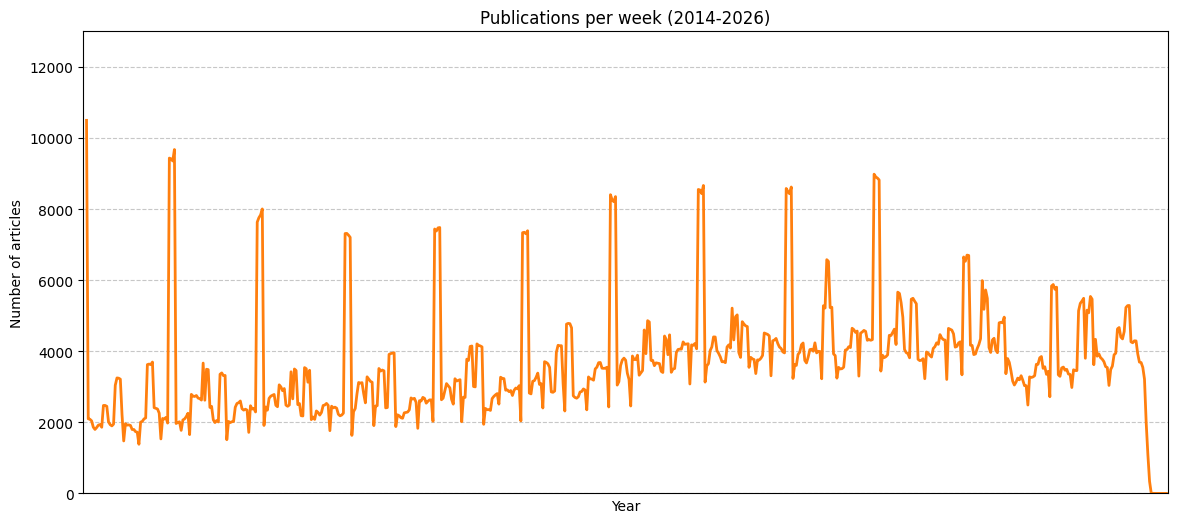

In [28]:
# Figure creation

# Import dataframe
file_path = "clean_df_step4.csv"

os.chdir(updated_files_directory)
#clean_df_step4 = pd.read_csv(file_path)
#figure_df = clean_df_step4.copy()
    
figure_df['PubDate'] = pd.to_datetime(figure_df['PubDate'], errors='coerce')
figure_df['Year'] = figure_df['PubDate'].dt.year
figure_df['YearMonth'] = figure_df['PubDate'].dt.to_period('M').astype(str)
figure_df['YearWeek'] = figure_df['PubDate'].dt.to_period('W').astype(str)
figure_df = figure_df[figure_df['Year'].between(2014, 2026)]
yearly_counts = figure_df['Year'].value_counts().sort_index()
monthly_counts = figure_df['YearMonth'].value_counts().sort_index()
weekly_counts = figure_df['YearWeek'].value_counts().sort_index()
years = list(range(2015, 2028))
shifted_labels = list(range(2014, 2027))
colors = plt.cm.tab20.colors

print("Success!")

# ====== Yearly Publications ======
plt.figure(figsize=(10, 6))
plt.bar(yearly_counts.index + 1, yearly_counts.values, color=colors[0])  # Shift years +1 for alignment

# Styling
plt.xlabel('Year')
plt.ylabel('Number of articles')
plt.title('Publications per year (2014-2026)')
plt.xlim(2014, 2026)
plt.ylim(0, yearly_counts.max() * 1.1)
plt.xticks(years, shifted_labels) 
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# ====== Monthly Publications ======
plt.figure(figsize=(14, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linestyle='-', color=colors[1], linewidth=2)
plt.xticks([f"{year}-01" for year in range(2014, 2027)], range(2014, 2027))

plt.xlabel('Year')
plt.ylabel('Number of articles')
plt.title('Publications per month (2014-2026)')
plt.xlim(monthly_counts.index.min(), monthly_counts.index.max())
plt.ylim(0, monthly_counts.max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# ====== Weekly Publications ======
plt.figure(figsize=(14, 6))

weekly_counts_smoothed = weekly_counts.rolling(window=4, center=True).mean()
plt.plot(weekly_counts.index, weekly_counts_smoothed, linestyle='-', color=colors[2], linewidth=2)
plt.xticks([f"{year}-W01" for year in range(2024, 2027)], range(2024, 2027))

plt.xlabel('Year')
plt.ylabel('Number of articles')
plt.title('Publications per week (2014-2026)')
plt.xlim(weekly_counts.index.min(), weekly_counts.index.max())
#plt.ylim(0, weekly_counts.max() * 1.1)
plt.ylim(0, 13000)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

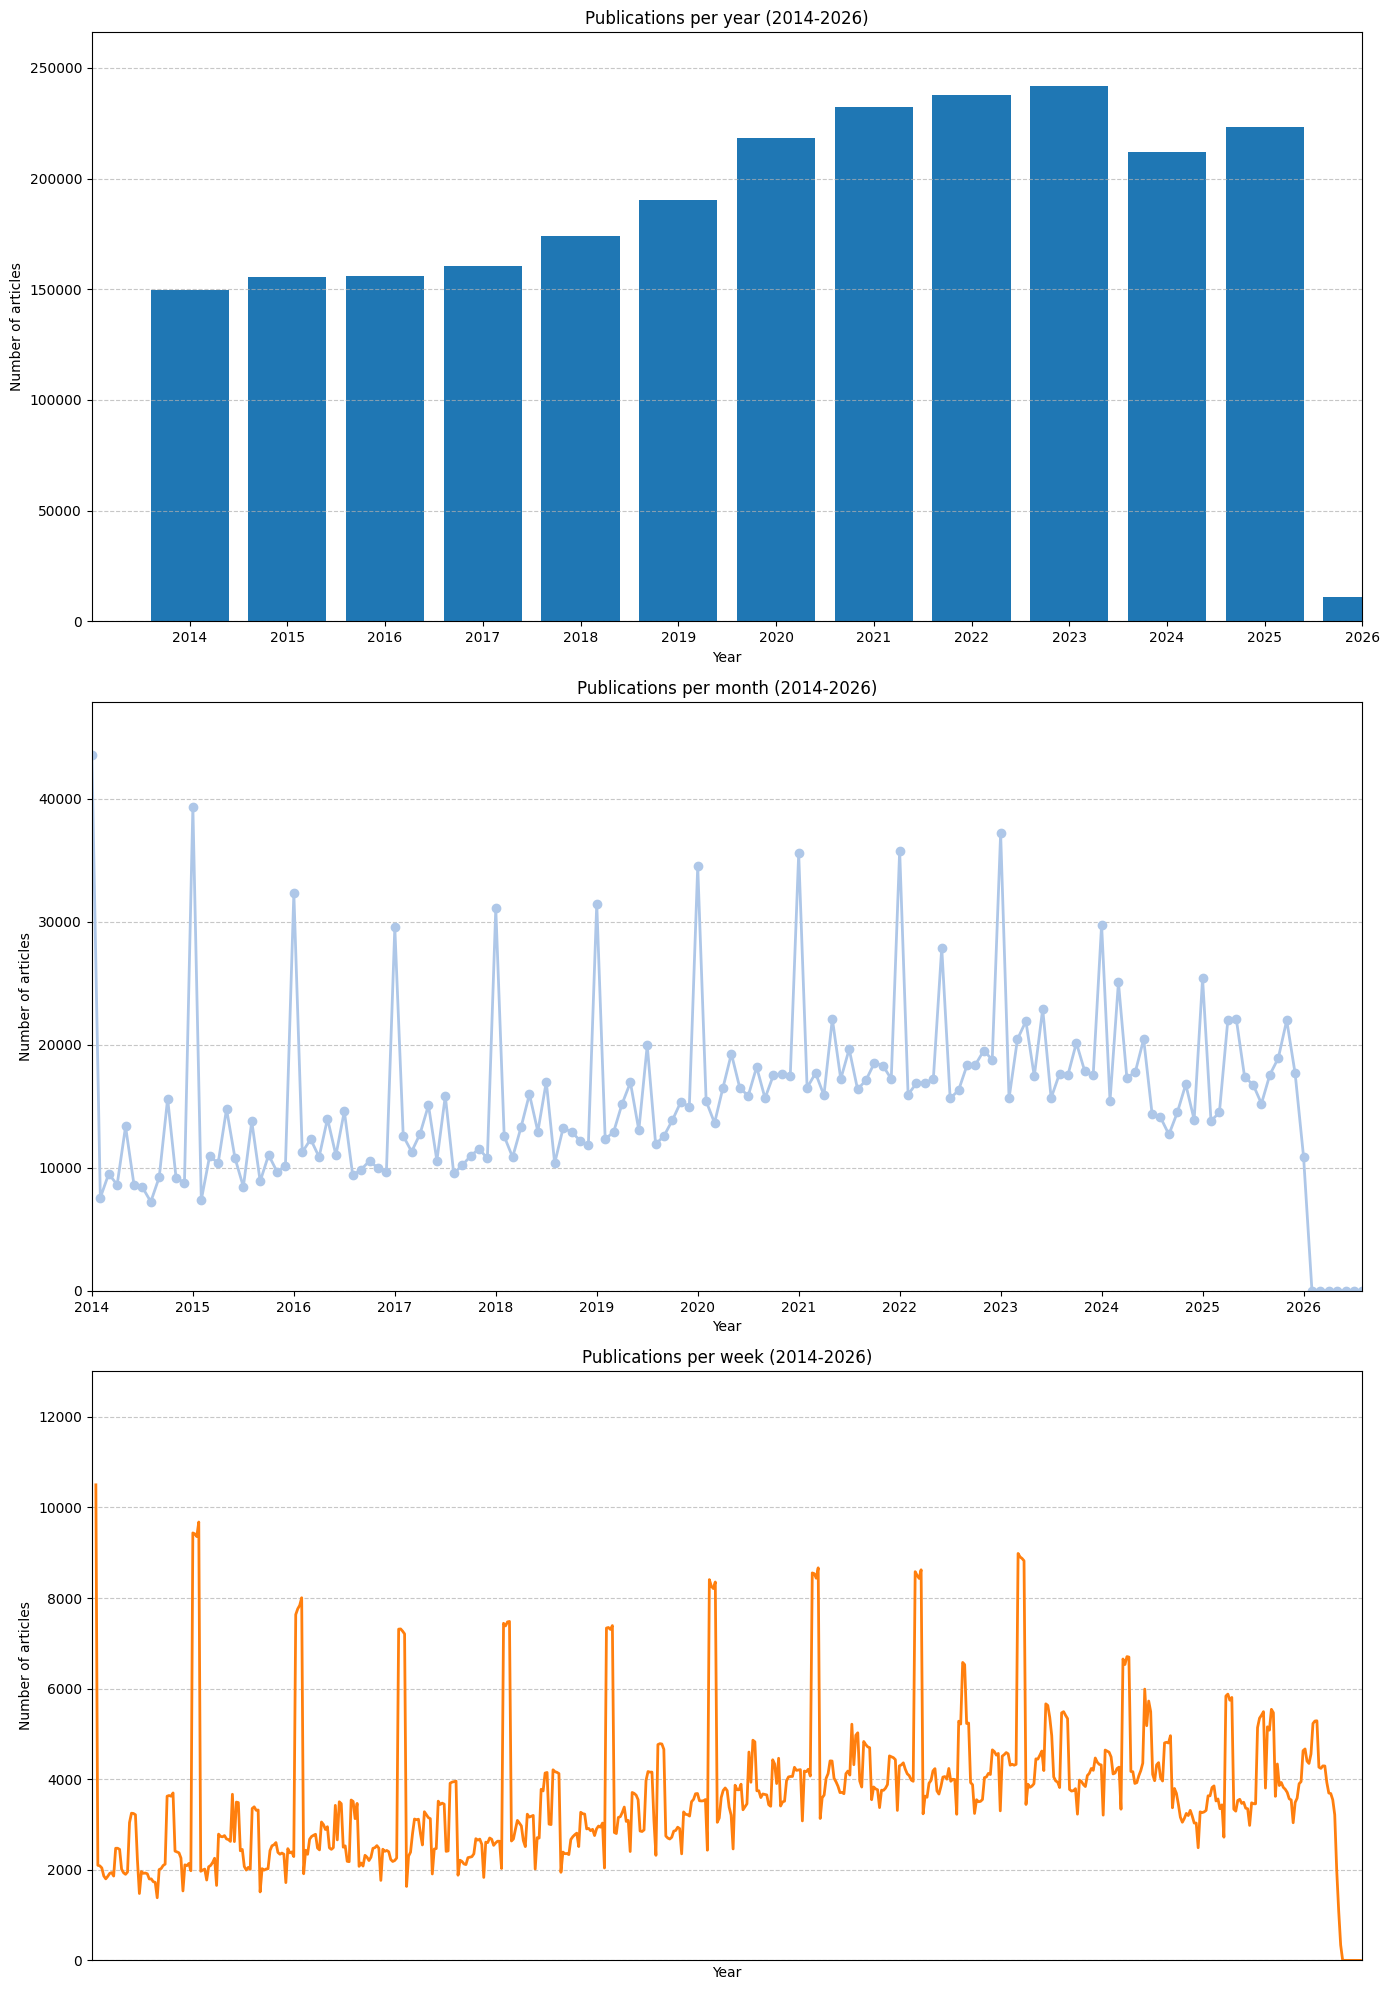

In [37]:
## Single figure

# ====== Combined Figure ======
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 20))
colors = plt.cm.tab20.colors

# ====== Yearly Publications ======
ax1.bar(yearly_counts.index + 1, yearly_counts.values, color=colors[0])

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of articles')
ax1.set_title('Publications per year (2014-2026)')
ax1.set_xlim(2014, 2026)
ax1.set_ylim(0, yearly_counts.max() * 1.1)
ax1.set_xticks(years)
ax1.set_xticklabels(shifted_labels)
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# ====== Monthly Publications ======
ax2.plot(monthly_counts.index, monthly_counts.values,
         marker='o', linestyle='-', color=colors[1], linewidth=2)

ax2.set_xticks([f"{year}-01" for year in range(2014, 2027)])
ax2.set_xticklabels(range(2014, 2027))

ax2.set_xlabel('Year')
ax2.set_ylabel('Number of articles')
ax2.set_title('Publications per month (2014-2026)')
ax2.set_xlim(monthly_counts.index.min(), monthly_counts.index.max())
ax2.set_ylim(0, monthly_counts.max() * 1.1)
ax2.grid(axis='y', linestyle='--', alpha=0.7)


# ====== Weekly Publications ======
weekly_counts_smoothed = weekly_counts.rolling(window=4, center=True).mean()

ax3.plot(weekly_counts.index, weekly_counts_smoothed,
         linestyle='-', color=colors[2], linewidth=2)

ax3.set_xticks([f"{year}-W01" for year in range(2024, 2027)])
ax3.set_xticklabels(range(2024, 2027))

ax3.set_xlabel('Year')
ax3.set_ylabel('Number of articles')
ax3.set_title('Publications per week (2014-2026)')
ax3.set_xlim(weekly_counts.index.min(), weekly_counts.index.max())
ax3.set_ylim(0, 13000)
ax3.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()

figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_sup_1.png", bbox_inches='tight', dpi=300)

plt.show()

## Supplementary figure 2

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_31704/2877459934.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mentions_distribution.index, y=mentions_distribution.values, palette=colors, edgecolor='black')


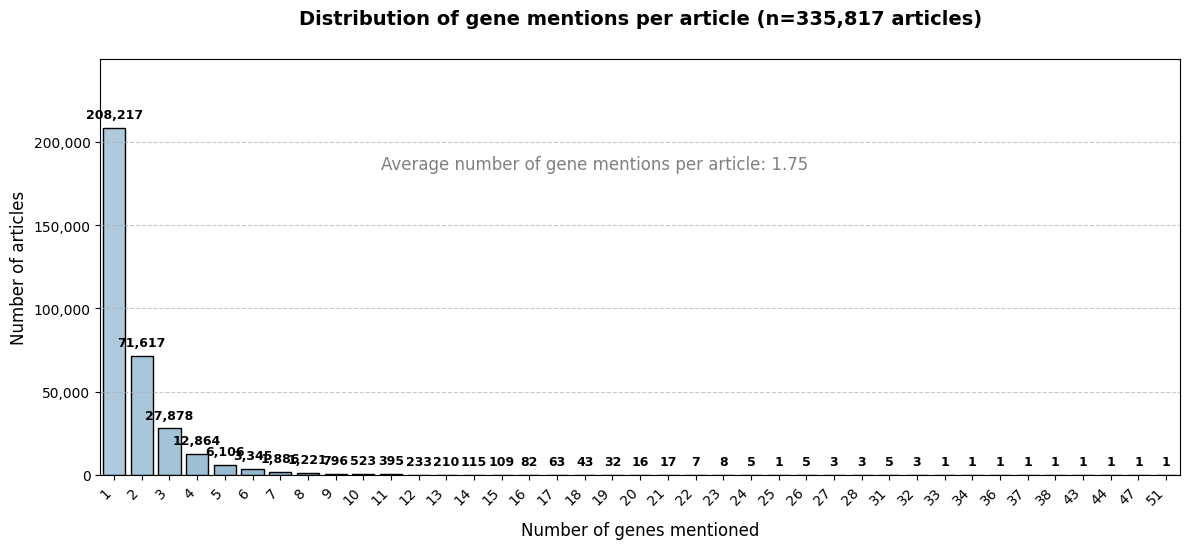

In [6]:
# Distribution of gene mentions per article

%matplotlib inline  

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("Blues_d", len(mentions_distribution))  
ax = sns.barplot(x=mentions_distribution.index, y=mentions_distribution.values, palette=colors, edgecolor='black')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title(f'Distribution of gene mentions per article (n={total_articles:,.0f} articles)', fontsize=14, fontweight='bold', pad=25)
plt.figtext(0.5, 0.6, f'Average number of gene mentions per article: {average_mentions:,.2f}', fontsize=12, color='gray', ha='center')
ax.set_xlabel('Number of genes mentioned', fontsize=12, labelpad=10)
ax.set_ylabel('Number of articles', fontsize=12)
ax.set_xticks(range(len(mentions_distribution.index)))

ax.set_xticklabels(mentions_distribution.index, fontsize=10)
for tick in ax.get_xticklabels():
    tick.set_rotation(45)
    tick.set_horizontalalignment('right')
    tick.set_position((tick.get_position()[0] - 0.05, tick.get_position()[1]))
ax.set_ylim(0, max(mentions_distribution.values) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar, value in zip(ax.patches, mentions_distribution.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (max(mentions_distribution.values) * 0.02), f"{value:,}", ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')

    fig.tight_layout(rect=[0, 0.05, 1, 0.85])

figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_sup_2.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_sup_2.svg", bbox_inches='tight')
plt.show()

## Supplementary figure 3

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_4386/209625011.py:3: DtypeWarning:

Columns (0: Study Type) have mixed types. Specify dtype option on import or set low_memory=False.

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_4386/209625011.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




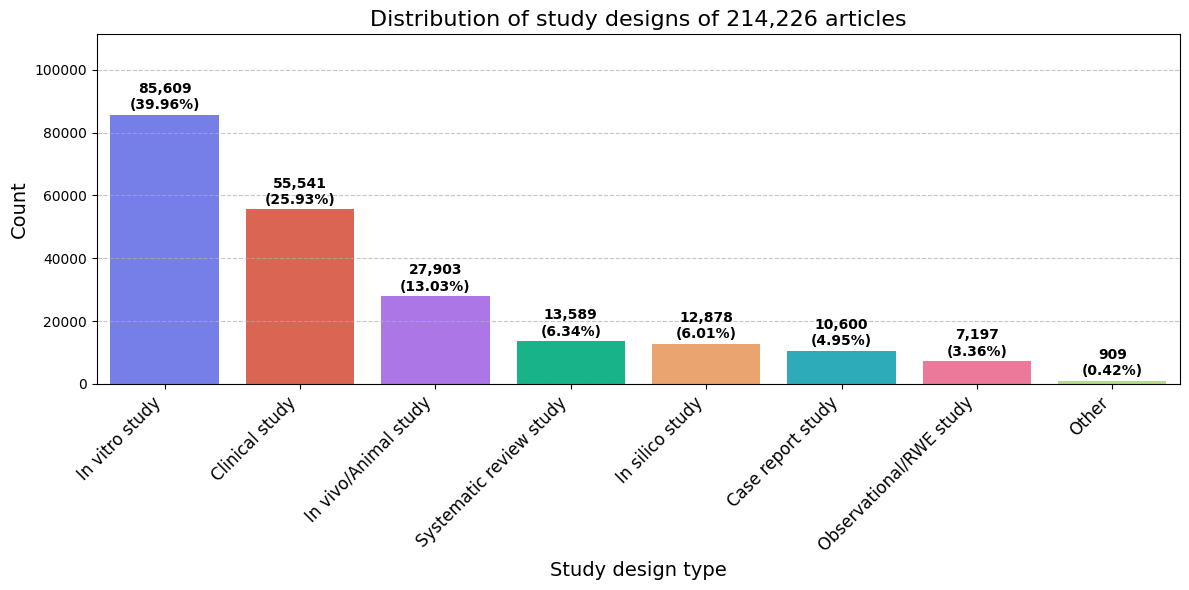

In [12]:
# Distribution of study designs
dataset_to_display = f"{updated_files_directory}/final_gc_classificaton_output_214224.csv"
stud_cat = pd.read_csv(dataset_to_display)

stud_cat["Study_design_clean"] = stud_cat["Study_design"].replace({
    "Behavioral study": "Other",
    "Undefined": "Other",
    "undefined": "Other"
})

# Count and calculate percentages
study_counts = stud_cat["Study_design_clean"].value_counts()

study_counts['In vitro study'] += 1
study_counts['Systematic review study'] += 1

total_count = study_counts.sum()
percentages = (study_counts / total_count * 100).round(2)
total_articles_with_specific_cancer_types = total_count

study_counts_df = pd.DataFrame({
    "Study Design": study_counts.index,
    "Count": study_counts.values,
    "Percentage": percentages.values
})


# Update color mapping with "Other" instead of individual undefined/behavioral
color_mapping = {
    "In vitro study": "#636EFA",
    "Clinical study": "#EF553B",
    "Systematic review study": "#00CC96",
    "In vivo/Animal study": "#AB63FA",
    "In silico study": "#FFA15A",
    "Case report study": "#17becf",
    "Observational/RWE study": "#FF6692",
    "Other": "#B6E880"  
}


colors = [color_mapping.get(study, "#333333") for study in study_counts_df["Study Design"]]
plt.figure(figsize=(12, 6))
bars = sns.barplot(x=study_counts_df["Study Design"], y=study_counts_df["Count"], palette=colors)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.xlabel("Study design type", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.title(f"Distribution of study designs of {total_articles_with_specific_cancer_types:,} articles", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, study_counts_df["Count"].max() * 1.3)

for bar, count, percentage in zip(bars.patches, study_counts_df["Count"], study_counts_df["Percentage"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, 
        height + (study_counts_df["Count"].max() * 0.01),  
        f"{int(count):,}\n({percentage}%)",  # Newline label
        ha="center", va="bottom", fontsize=10, fontweight='bold'
    )

plt.tight_layout()

figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_sup_3.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_sup_3.svg", bbox_inches='tight')

plt.show()

## Supplementary figure 4

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_4752/1670990596.py:6: DtypeWarning: Columns (0: CoFoS) have mixed types. Specify dtype option on import or set low_memory=False.
  treatment_mapping_df = pd.read_csv('../../file_merging/Updated/treatment_mapping_with_matches.csv')


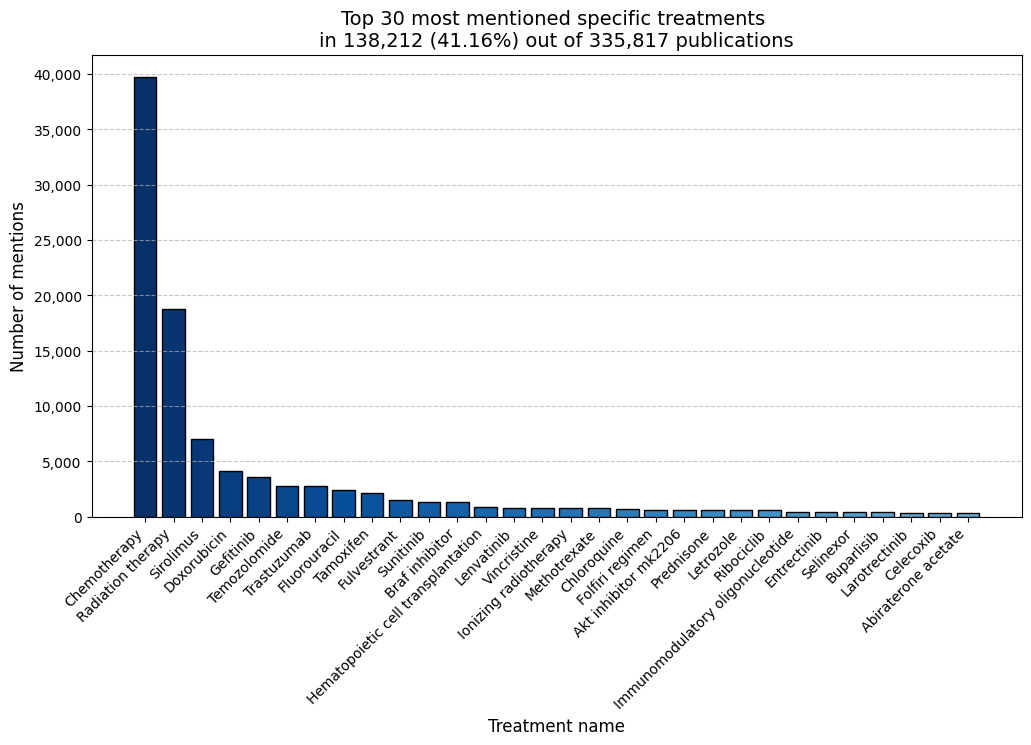

In [1]:
import pandas as pd
import matplotlib.pylab as plt
import numpy as np
import matplotlib.ticker as mticker

treatment_mapping_df = pd.read_csv('../../file_merging/Updated/treatment_mapping_with_matches.csv')

num_zero_treatments = (treatment_mapping_df["Sum_treatments"] == 0).sum()
num_nonzero_treatments = (treatment_mapping_df["Sum_treatments"] >= 1).sum()

# Plot the top 30 most mentioned treatments as a bar chart
if "Sum_Gene_Mentions" in treatment_mapping_df.columns:
    start_index = treatment_mapping_df.columns.get_loc("Sum_Gene_Mentions") + 1
else:
    start_index = 0
end_index = treatment_mapping_df.columns.get_loc("Treatment_matches")
treatment_counts = treatment_mapping_df.iloc[:, start_index:end_index].sum().sort_values(ascending=False)
treatment_counts = treatment_counts.drop(index=['TP53', 'AKT1', 'BRCA2', 'CDK4', 'NF2', 'ERBB2', 'ATM', 'JAK1', 'ESR1', 'RET', 'PDGFRA', 'IGF1R', 'RB1',
                             'ROS1', 'JAK2', 'RHOA', '4', 'ATR', 'ARID1A', 'PALB2', 'STK11', 'IDH2', 'PTCH1', 'TSC2', 'GNAS', 'FANCA',
                             'MRE11', 'NOTCH2', 'NOTCH3', 'RAD50', 'MAX', 'MDM4', 'ERCC2', '15', 'JAK3', 'HNF1A', 'NTRK2', 'H3F3A'])
top_20_treatments = treatment_counts.head(30)
colors = plt.cm.Blues(np.linspace(1, 0.5, len(top_20_treatments)))
formatted_labels = [name.capitalize() for name in top_20_treatments.index]
plt.figure(figsize=(12, 6))
bars = plt.bar(formatted_labels, top_20_treatments.values, color=colors, edgecolor='black')

total_mentions = treatment_counts.sum()

total_rows = len(treatment_mapping_df)

'''for bar in bars:
    height = bar.get_height()
    percent = 100 * height / total_rows
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}\n({percent:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=80
    )'''

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Treatment name", fontsize=12)
plt.ylabel("Number of mentions", fontsize=12)
#plt.ylim(0, 50000)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
perc = 100 * (num_nonzero_treatments / total_rows)
plt.title(f"Top 30 most mentioned specific treatments \nin {num_nonzero_treatments:,} ({perc:.2f}%) out of {total_rows:,} publications", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_sup_4.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_sup_4.svg", bbox_inches='tight')

plt.show()

In [7]:
'''treatment_counts.drop(index=['TP53', 'AKT1', 'BRCA2', 'CDK4', 'NF2', 'ERBB2', 'ATM', 'JAK1', 'ESR1', 'RET', 'PDGFRA', 'IGF1R', 'RB1',
                             'ROS1', 'JAK2', 'RHOA', '4', 'ATR', 'ARID1A', 'PALB2', 'STK11', 'IDH2', 'PTCH1', 'TSC2', 'GNAS', 'FANCA',
                             'MRE11', 'NOTCH2']).head(30)'''
treatment_counts.drop(index=['NOTCH3', 'RAD50', 'MAX', 'MDM4', 'ERCC2', '15', 'JAK3', 'HNF1A', 'NTRK2', 'H3F3A']).head(30)

Chemotherapy                          39775
Radiation Therapy                     18742
Sirolimus                              7024
Doxorubicin                            4102
Gefitinib                              3590
Temozolomide                           2783
Trastuzumab                            2735
Fluorouracil                           2408
Tamoxifen                              2110
Fulvestrant                            1474
Sunitinib                              1329
BRAF Inhibitor                         1297
Hematopoietic Cell Transplantation      853
Lenvatinib                              768
Vincristine                             762
Ionizing Radiotherapy                   759
Methotrexate                            740
Chloroquine                             715
FOLFIRI Regimen                         620
Akt Inhibitor MK2206                    619
Prednisone                              583
Letrozole                               578
Ribociclib                      

## Supplementary figure 5

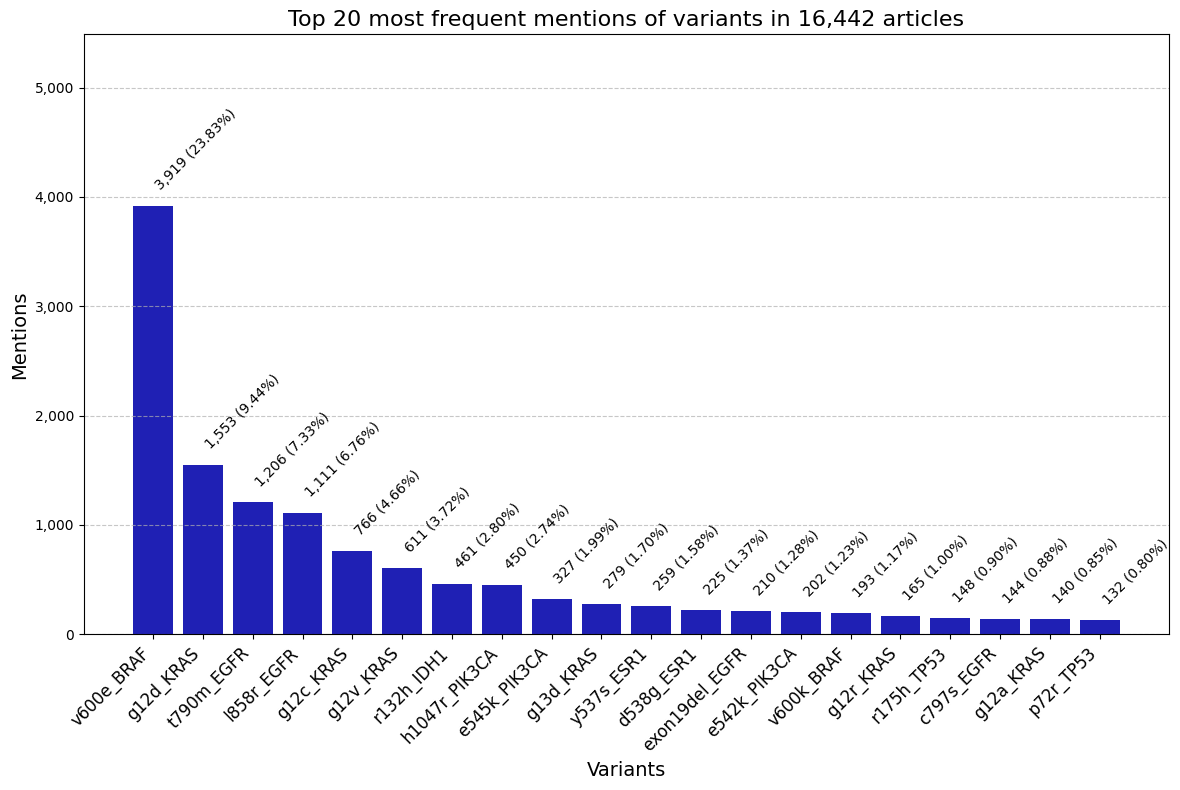

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Top 20 most frequent variant mentions

top_20_csv_path = "../../file_merging/Updated/Top_20_Variants.csv"
top_20_df = pd.read_csv(top_20_csv_path)

if "Percentage" not in top_20_df.columns:
    raise ValueError("The 'Percentage' column is missing from the loaded CSV file. Please check file.")

total_mentions = top_20_df["Count"].sum()
sum_of_percentages = top_20_df["Percentage"].sum()
total_articles_estimate = int(total_mentions / (sum_of_percentages / 100))

plt.figure(figsize=(12, 8))
bars = plt.bar(top_20_df["Variant"], top_20_df["Count"], color='#1f20b4')

plt.title(f'Top 20 most frequent mentions of variants in {total_articles_estimate:,} articles', fontsize=16)
plt.xlabel('Variants', fontsize=14)
plt.ylabel('Mentions', fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.ylim(0, top_20_df["Count"].max() * 1.4)

plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (count, percentage) in enumerate(zip(top_20_df["Count"], top_20_df["Percentage"])):
    plt.text(i, count + (top_20_df["Count"].max() * 0.03), 
             f"{int(count):,} ({percentage:.2f}%)", 
             ha='left', va='bottom', fontsize=10, fontweight='normal', 
             rotation=45, rotation_mode='default')  

plt.tight_layout()

figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_sup_5.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_sup_5.svg", bbox_inches='tight')

plt.show()

## Supplementary figure 6

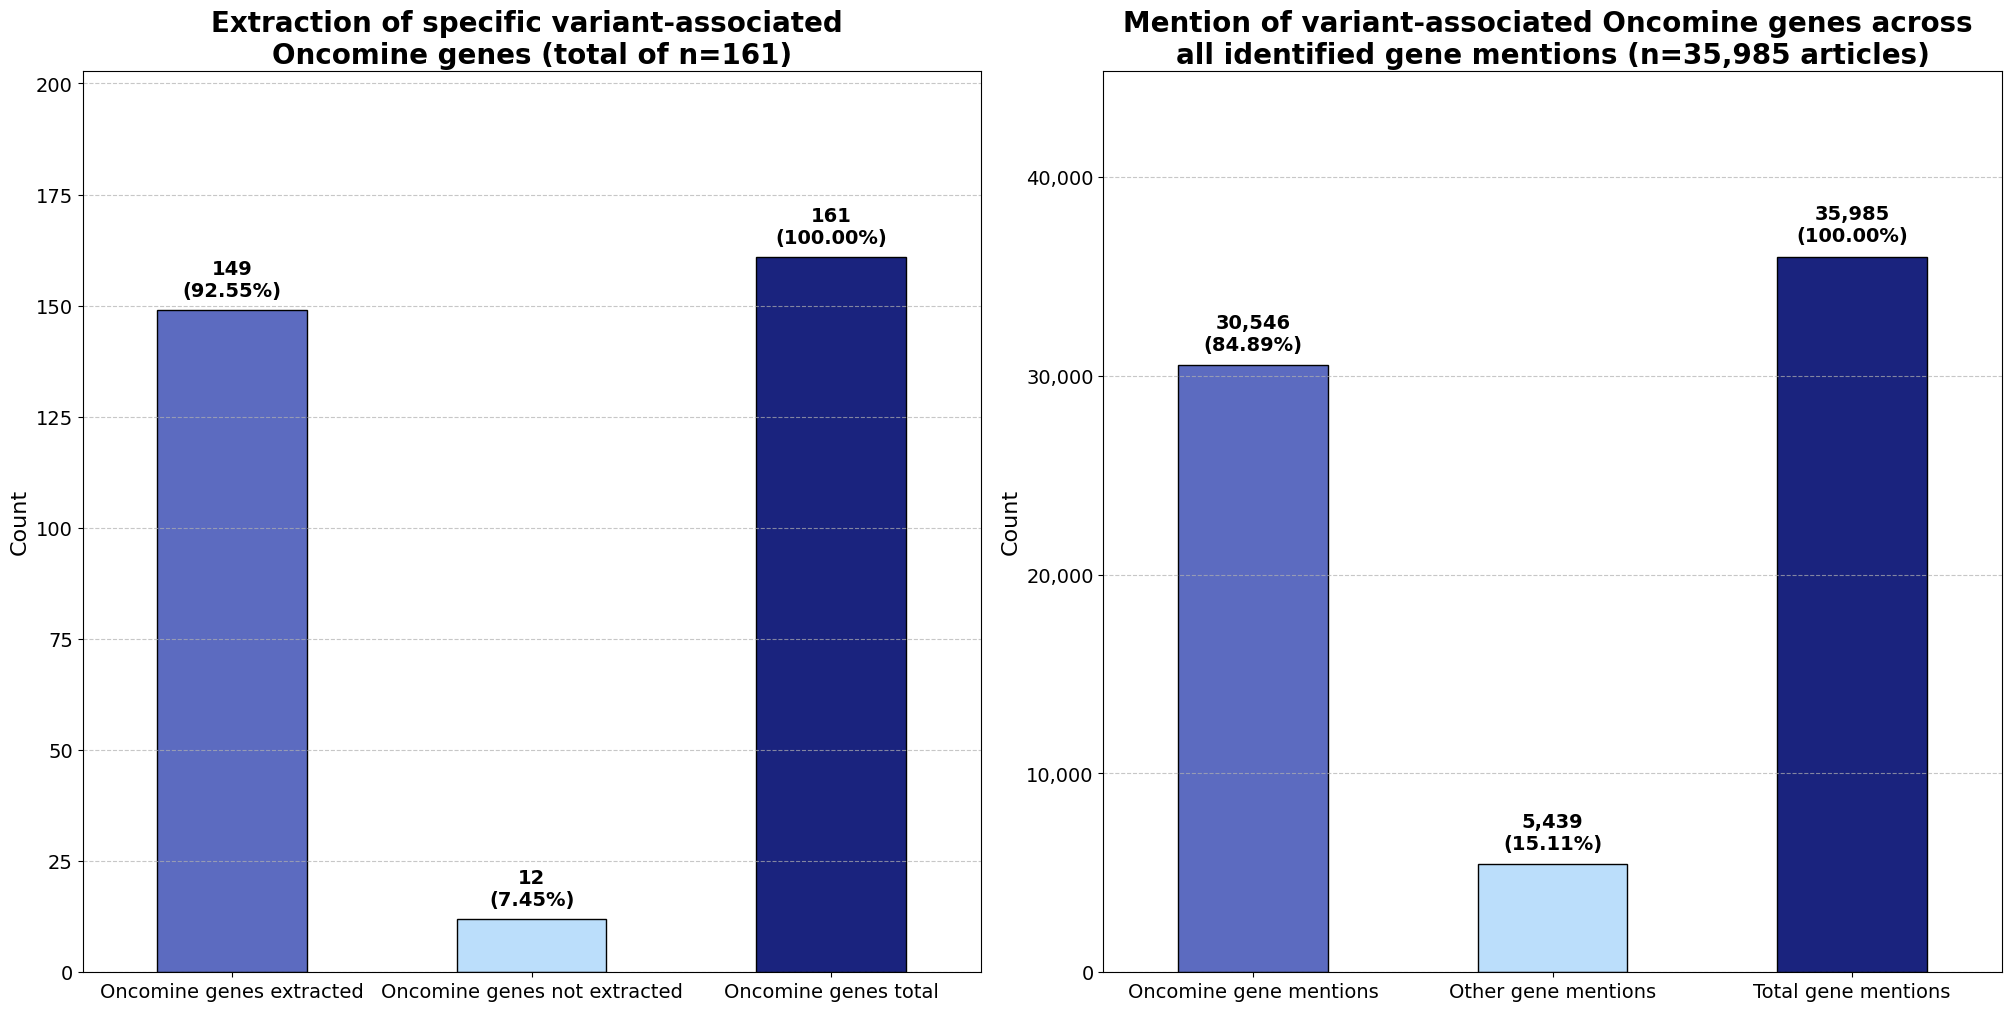

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Oncomine figure
top_20_csv_path = "../../file_merging/Updated/oncomine_gene_summary_stats_forfigure.csv"
df_summary = pd.read_csv(top_20_csv_path)

# Define categories to include for each plot and ensure correct order
counts_categories = [
    "Oncomine genes extracted",  
    "Oncomine genes not extracted",  
    "Oncomine genes total"  
]

percentages_categories = [
    "Oncomine gene mentions", 
    "Other gene mentions", 
    "Total gene mentions"
]

counts_data = df_summary[df_summary['Category'].isin(counts_categories)][['Category', 'Count', 'Percentage']].copy()
counts_data['Count'] = pd.to_numeric(counts_data['Count'], errors='coerce')
counts_data['Percentage'] = pd.to_numeric(counts_data['Percentage'], errors='coerce')
counts_data = counts_data.set_index('Category').reindex(counts_categories).reset_index()

percentages_data = df_summary[df_summary['Category'].isin(percentages_categories)][['Category', 'Count', 'Percentage']].copy()
percentages_data['Count'] = pd.to_numeric(percentages_data['Count'], errors='coerce')
percentages_data['Percentage'] = pd.to_numeric(percentages_data['Percentage'], errors='coerce')
percentages_data = percentages_data.set_index('Category').reindex(percentages_categories).reset_index()

total_mentions_value = int(percentages_data[percentages_data['Category'] == 'Total gene mentions']['Count'].values[0])
formatted_total_mentions = f"{total_mentions_value:,}"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10), constrained_layout=True)
royal_blue = '#1A237E'
lighter_blue = '#5C6BC0'
light_light_blue = '#BBDEFB'

left_axis_range = counts_data['Count'].max() * 1.26
right_axis_range = percentages_data['Count'].max() * 1.26

left_padding = left_axis_range * 0.01
right_padding = right_axis_range * 0.01

additional_padding_left = 1
additional_padding_right = 300

def plot_labels(ax, data, padding, additional_padding):
    for index, (count, percentage) in enumerate(zip(data['Count'], data['Percentage'])):
        if not pd.isna(count):
            label_text = f"{int(count):,}\n({percentage:.2f}%)"
            ax.text(index, count + padding + additional_padding, label_text, ha='center', fontsize=14, fontweight='bold', color='black')

# Plot 1: Counts (LEFT)
colors_left = [lighter_blue, light_light_blue, royal_blue] 
counts_data.plot(kind='bar', x='Category', y='Count', ax=ax1, color=colors_left, edgecolor='black', legend=False)
ax1.set_title('Extraction of specific variant-associated \nOncomine genes (total of n=161)', 
              fontsize=20, fontweight='bold', pad=5)
ax1.set_xlabel('', fontsize=16)
ax1.set_ylabel('Count', fontsize=16)
ax1.tick_params(axis='x', rotation=0, labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_ylim(0, left_axis_range)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.grid(axis='y', linestyle='--', alpha=0.7)

plot_labels(ax1, counts_data, left_padding, additional_padding_left)

# Plot 2: Percentages (RIGHT)
colors_right = [lighter_blue, light_light_blue, royal_blue] 
percentages_data.plot(kind='bar', x='Category', y='Count', ax=ax2, color=colors_right, edgecolor='black', legend=False)
ax2.set_title(f'Mention of variant-associated Oncomine genes across \nall identified gene mentions (n={formatted_total_mentions} articles)', 
              fontsize=20, fontweight='bold', pad=5)
ax2.set_xlabel('', fontsize=16)
ax2.set_ylabel('Count', fontsize=16)
ax2.tick_params(axis='x', rotation=0, labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_ylim(0, right_axis_range)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plot_labels(ax2, percentages_data, right_padding, additional_padding_right)

figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_sup_6.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_sup_6.svg", bbox_inches='tight')
plt.show()

## Supplementary figure 7

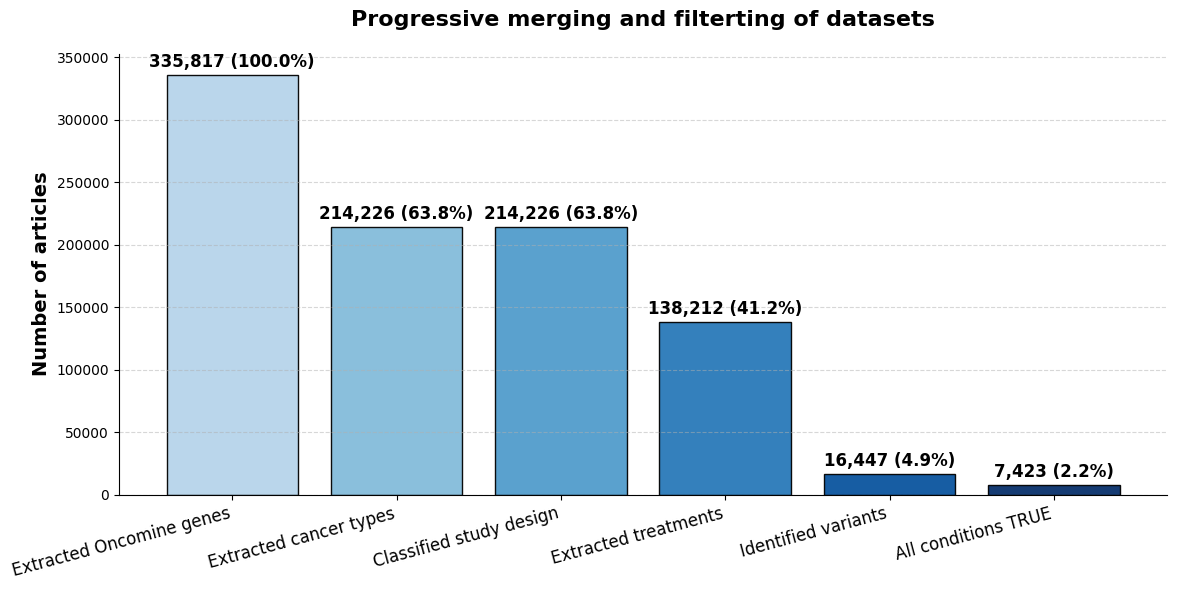

In [17]:
#Progressive merging and fitlerting of datasets

csv_path = "../../file_merging/Updated/conditional_filterting_of_final_datasets_for_coassciaitions_analysis.csv"
dataset_lengths_df = pd.read_csv(csv_path)
counts = dataset_lengths_df['Count'].tolist()

counts[2] += 2 

count_1 = counts[0]
percentages = [(count / count_1 * 100) if count_1 > 0 else 0 for count in counts]
labels = [
    "Extracted Oncomine genes",
    "Extracted cancer types",
    "Classified study design", 
    "Extracted treatments",   
    "Identified variants",
    "All conditions TRUE"
]
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.Blues(np.linspace(0.3, 1, len(labels))) 
bars = ax.bar(labels, counts, color=colors, edgecolor='black', alpha=0.95)
for bar, count, pct in zip(bars, counts, percentages):
    label = f"{count:,} ({pct:.1f}%)"
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            label,
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title("Progressive merging and filterting of datasets", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Number of articles", fontsize=14, fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=12, ha="right", rotation=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

figures_dir = '../../final_figures'
plt.savefig(f"{figures_dir}/Figure_sup_7.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{figures_dir}/Figure_sup_7.svg", bbox_inches='tight')

plt.show()

## Supplementary figure 8

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_4004/328953452.py:54: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.05, right=0.99, bottom=0.35, top=0.95)


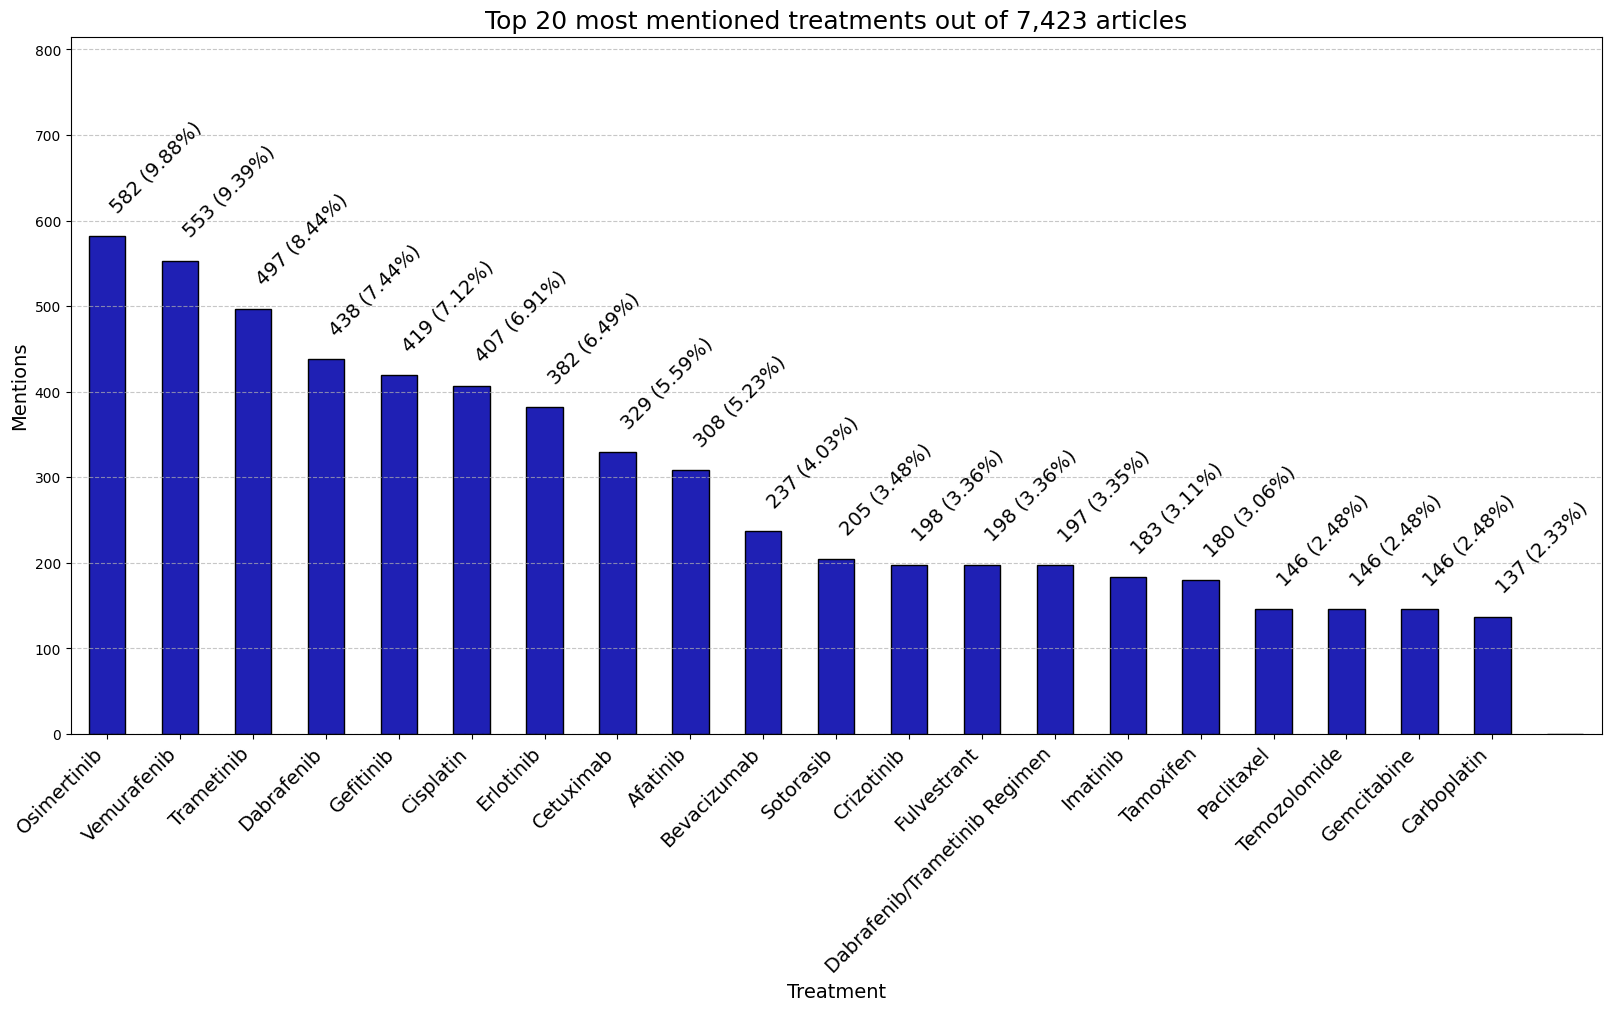

In [4]:
treatment_columns = dictionary[dictionary['Category'] == "Treatment"]["Column_Name"].tolist()
treatment_df = coas_variant_df[treatment_columns]
top_treatments = treatment_df.sum()
# EXCLUDE SPECIFIC TREATMENTS
excluded_treatments = [
    'chemotherapy',
    'immunotherapy',
    'hormone therapy',
    'radiation therapy',
    'adjuvant chemotherapy',
    'radiation ionizing radiotherapy',
    'tyrosine kinase inhibitor',
    'braf inhibitor'
]
top_treatments = top_treatments[~top_treatments.index.str.lower().isin([t.lower() for t in excluded_treatments])]
top_treatments = top_treatments.sort_values(ascending=False).head(20)
top_treatments_percent = (top_treatments / total_articles) * 100

figures_dir = '../../final_figures'
plot_and_save_bar_chart(top_treatments, 'Top 20 most mentioned treatments', 'Treatment', 'Mentions', 
                        os.path.join(figures_dir, 'Figure_sup_8.png'), total_articles)

## Supplementary figure 9

/var/folders/57/yk3w62md44z9m6ndy61mkkz80000gn/T/ipykernel_4004/328953452.py:54: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(left=0.05, right=0.99, bottom=0.35, top=0.95)


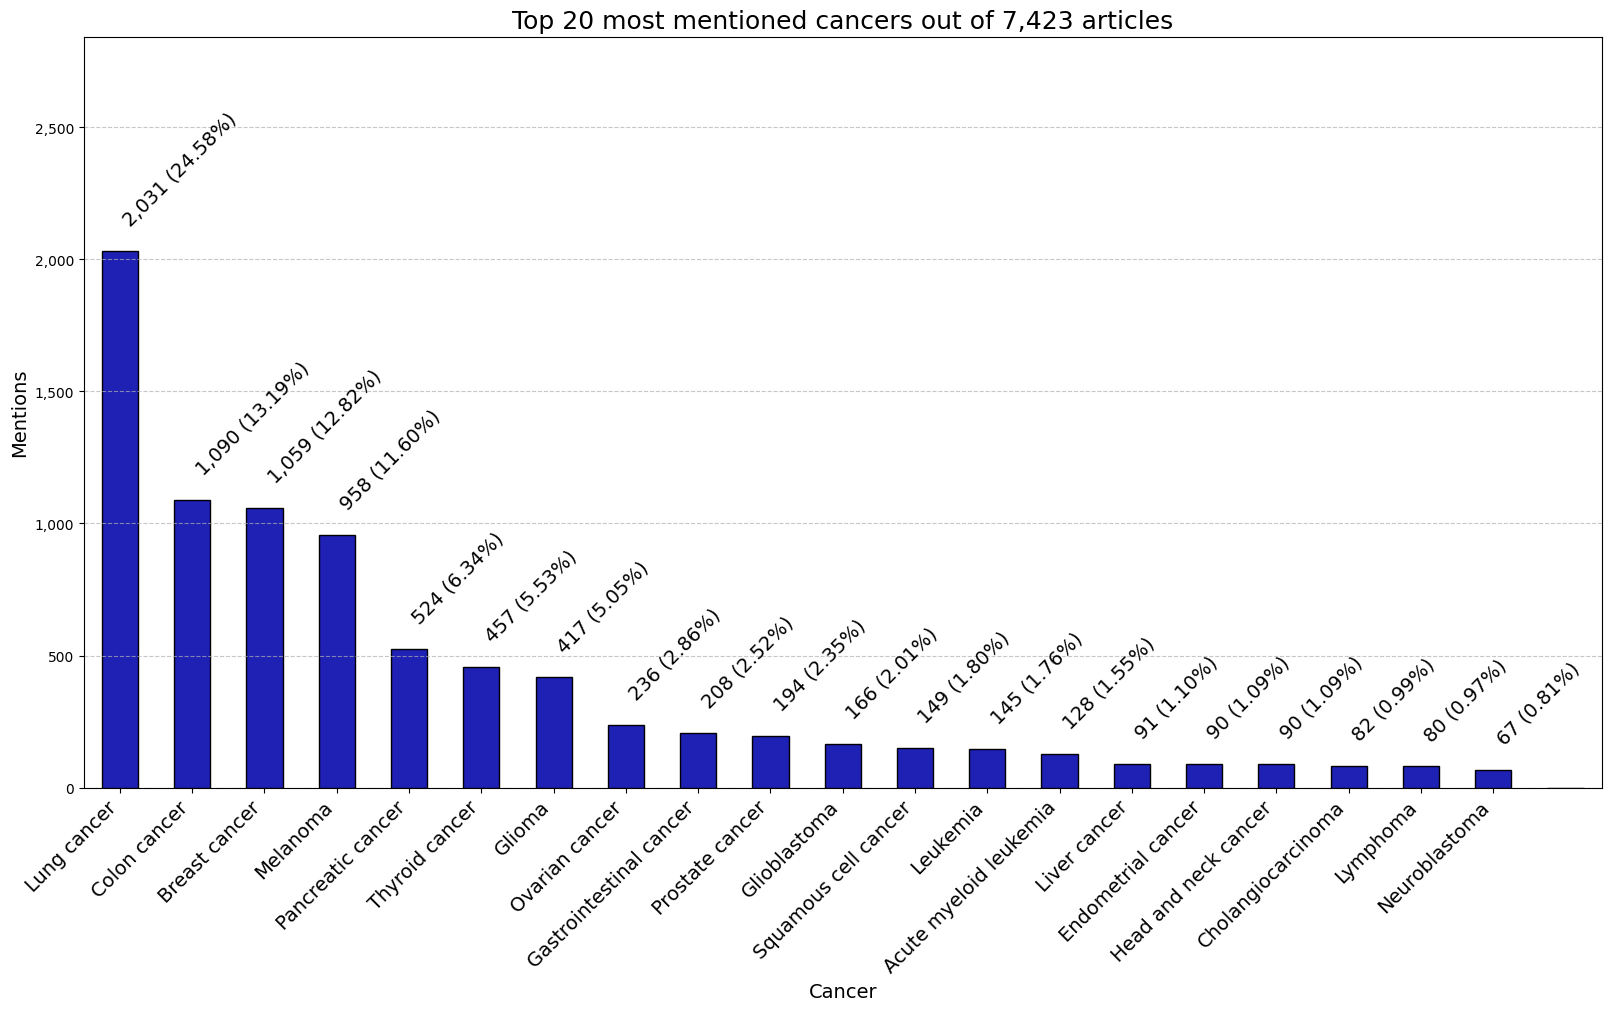

In [6]:
cancer_columns = dictionary[dictionary['Category'] == "Cancer"]["Column_Name"].tolist()
cancer_df = coas_variant_df[cancer_columns]
top_cancers = cancer_df.sum().sort_values(ascending=False).head(20)
top_cancers.index = top_cancers.index.str.capitalize()
top_cancers_percent = (top_cancers / total_articles) * 100

plot_and_save_bar_chart(top_cancers, 'Top 20 most mentioned cancers', 'Cancer', 'Mentions', 
                        os.path.join(figures_dir, 'Figure_sup_9.png'), total_articles)

## Supplementary figure 10

In [7]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# ----------- Matrix Functions -----------

# Generate raw co-occurrence matrix
def co_occurrence_matrix(df1, df2, weights, scaling_factor=1.0):
    weights = weights * scaling_factor
    weighted_df1 = df1.mul(weights, axis=0)
    weighted_df2 = df2.mul(weights, axis=0)
    raw_matrix = weighted_df1.T.dot(weighted_df2)
    return raw_matrix

# Normalize co-occurrence matrix by row totals (%)
def normalize_matrix(raw_matrix, df1, weights, scaling_factor=1.0):
    weights = weights * scaling_factor
    weighted_df1 = df1.mul(weights, axis=0)
    row_totals = weighted_df1.sum(axis=0)
    percentage_matrix = raw_matrix.div(row_totals, axis=0).mul(100)
    return percentage_matrix

# ----------- Statistical Testing -----------

def apply_statistical_testing(raw_matrix):
    print(f"Applying statistical tests to matrix of size {raw_matrix.shape}...")

    # Replace NaNs with 0 to prevent integer conversion errors
    raw_matrix = raw_matrix.fillna(0)

    p_values = []
    matrix_shape = raw_matrix.shape
    flattened_matrix = raw_matrix.values.flatten()
    total_sum = np.sum(flattened_matrix)
    
    for value in tqdm(flattened_matrix, desc="Processing statistical tests", total=len(flattened_matrix)):
        if value > 0:
            a = int(value)
            b = int(total_sum - a)
            c = int(np.sum(raw_matrix.sum(axis=1)) - a)
            d = int(total_sum)

            contingency_table = np.array([[a, b], [c, d]])
            try:
                _, p_value = fisher_exact(contingency_table)
            except Exception:
                p_value = 1.0
        else:
            p_value = 1.0
        p_values.append(p_value)

    print("Applying Benjamini-Hochberg correction...")
    corrected_p_values = multipletests(p_values, method='fdr_bh')[1]
    corrected_p_values_matrix = np.reshape(corrected_p_values, matrix_shape)
    return pd.DataFrame(corrected_p_values_matrix, index=raw_matrix.index, columns=raw_matrix.columns)

# ----------- Pipeline Execution -----------

print("Generating co-occurrence matrices (raw counts)...")
treatment_variant_raw = co_occurrence_matrix(treatment_df, variant_df, weights)
cancer_variant_raw = co_occurrence_matrix(cancer_df, variant_df, weights)
treatment_cancer_raw = co_occurrence_matrix(treatment_df, cancer_df, weights)
print("Co-occurrence matrices generated successfully!\n")

# Normalize for display
treatment_variant_matrix_normalized = normalize_matrix(treatment_variant_raw, treatment_df, weights)
cancer_variant_matrix_normalized = normalize_matrix(cancer_variant_raw, cancer_df, weights)
treatment_cancer_matrix_normalized = normalize_matrix(treatment_cancer_raw, treatment_df, weights)

# Apply Fisher's test and FDR correction
treatment_variant_pvalues = apply_statistical_testing(treatment_variant_raw)
cancer_variant_pvalues = apply_statistical_testing(cancer_variant_raw)
treatment_cancer_pvalues = apply_statistical_testing(treatment_cancer_raw)

Generating co-occurrence matrices (raw counts)...
Co-occurrence matrices generated successfully!

Applying statistical tests to matrix of size (623, 11676)...


Processing statistical tests: 100%|██████████| 7274148/7274148 [01:26<00:00, 83844.44it/s] 


Applying Benjamini-Hochberg correction...
Applying statistical tests to matrix of size (162, 11676)...


Processing statistical tests: 100%|██████████| 1891512/1891512 [00:14<00:00, 127643.69it/s]


Applying Benjamini-Hochberg correction...
Applying statistical tests to matrix of size (623, 162)...


Processing statistical tests: 100%|██████████| 100926/100926 [00:02<00:00, 45254.27it/s]

Applying Benjamini-Hochberg correction...


In [34]:
cancer_variant_matrix_normalized.to_csv('../../file_merging/Updated/cancer_variant_matrix_normalized.csv')
treatment_variant_matrix_normalized.to_csv('../../file_merging/Updated/treatment_variant_matrix_normalized.csv')
treatment_cancer_matrix_normalized.to_csv('../../file_merging/Updated/treatment_cancer_matrix_normalized.csv')

In [8]:
treatment_variant_pvalues.to_csv("../../file_merging/Updated/treatment_variant_pvalues.csv")
cancer_variant_pvalues.to_csv("../../file_merging/Updated/cancer_variant_pvalues.csv")
treatment_cancer_pvalues.to_csv("../../file_merging/Updated/treatment_cancer_pvalues.csv")

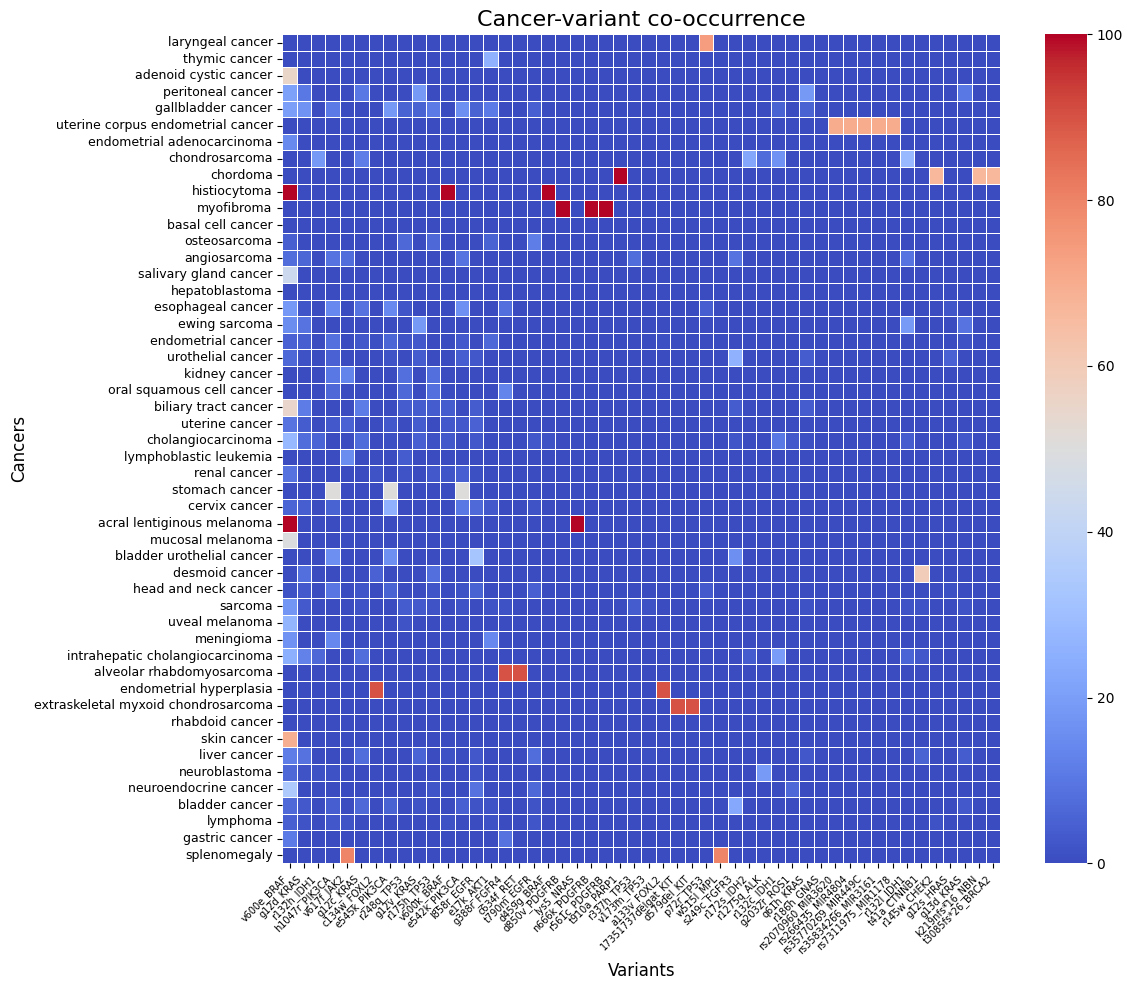

In [ ]:
# Display top 50 heatmaps
#treatment_variant_matrix = pd.read_csv(f"../../file_merging/Updated/treatment_variant_matrix_normalized.csv", index_col=0)
cancer_variant_matrix = pd.read_csv(f"../../file_merging/Updated/cancer_variant_matrix_normalized.csv", index_col=0)

# Function to plot filtered heatmaps
def plot_filtered_heatmap(matrix, title, filename, x_label, y_label, threshold=1.0, top_n=50):
    filtered_matrix = matrix[matrix > threshold].fillna(0)
    row_totals = filtered_matrix.sum(axis=1)
    col_totals = filtered_matrix.sum(axis=0)
    top_rows = row_totals.nlargest(top_n).index
    top_cols = col_totals.nlargest(top_n).index
    filtered_matrix = filtered_matrix.loc[top_rows, top_cols]
    plt.figure(figsize=(12, 10))
    sns.heatmap(filtered_matrix, cmap="coolwarm", annot=False, linewidths=0.5, cbar=True)
    plt.title(title, fontsize=16)
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    svg_filename = filename.replace('.png', '.svg')
    plt.savefig(svg_filename)
    plt.show()


# Plot heatmaps
'''plot_filtered_heatmap(treatment_variant_matrix, 
                      "Treatment-variant co-occurrence", 
                      "filtered_treatment_variant_heatmap.png", 
                      "Variants", "Treatments", 
                      threshold=1.0, top_n=50)'''

figures_dir = '../../final_figures'
plot_filtered_heatmap(cancer_variant_matrix, 
                      "Cancer-variant co-occurrence", 
                      f"{figures_dir}/Figure_suppl_10.png", 
                      "Variants", "Cancers", 
                      threshold=1.0, top_n=50)

In [2]:
import pandas as pd

cancer_variant_matrix = pd.read_csv(f"../../file_merging/Updated/cancer_variant_matrix_normalized.csv", index_col=0)
#top_20_variants_cancers = cancer_variant_matrix.stack().sort_values(ascending=False).head(20)

top_20_variants_cancers = (
    cancer_variant_matrix
    .stack()
    .rename("score")
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={
        "level_0": "cancer",
        "level_1": "variant"
    })
)

top_20_variants_cancers["score"] = top_20_variants_cancers["score"].round(3)
top_20_variants_cancers.insert(0, "rank", range(1, 21))
top_20_variants_cancers.to_csv('../../score_evaluation/top_20_variants_cancers.csv', index=False)
top_20_variants_cancers

,rank,cancer,variant,score
0,1,neurofibroma,v600e_BRAF,100.000
1,2,myofibroma,r561c_PDGFRB,100.000
2,3,myofibroma,d850v_PDGFRB,100.000
3,4,histiocytoma,d459g_BRAF,100.000
4,5,histiocytoma,v600e_BRAF,100.000
5,6,ocular melanoma,v600e_BRAF,100.000
6,7,myofibroma,n666k_PDGFRB,100.000
7,8,synovial sarcoma,r248q_TP53,100.000
8,9,clear cell sarcoma,v600e_BRAF,100.000
9,10,chordoma,t910a_PARP1,100.000


## Supplementary figure 11

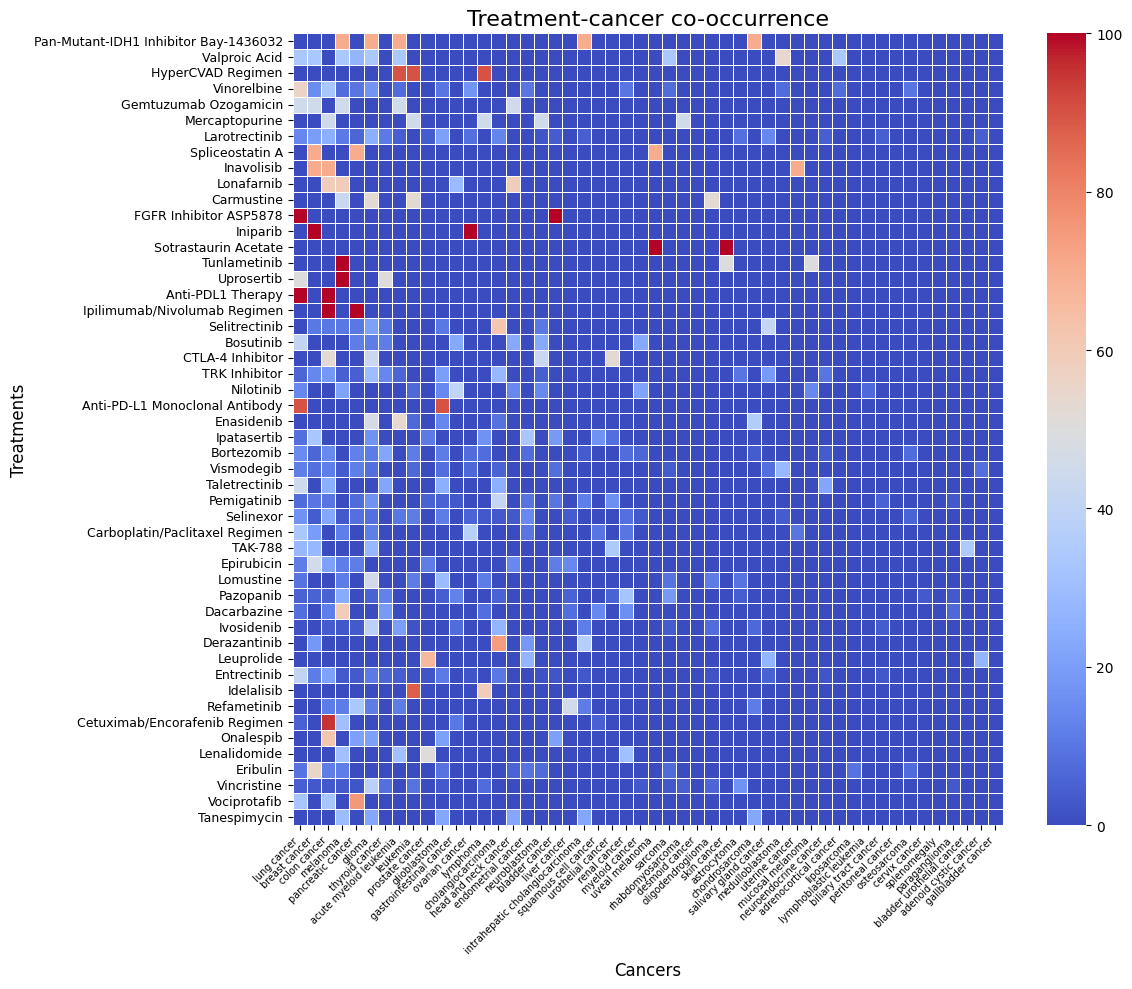

In [35]:
treatment_cancer_matrix = pd.read_csv(f"../../file_merging/Updated/treatment_cancer_matrix_normalized.csv", index_col=0)

plot_filtered_heatmap(treatment_cancer_matrix, 
                      "Treatment-cancer co-occurrence", 
                      f"{figures_dir}/Figure_suppl_11.png", 
                      "Cancers", "Treatments", 
                      threshold=1.0, top_n=50)

## Multipanel figures

In [11]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

# Paths to your figures
figures_dir = "../../final_figures"
fig_paths = [
    f'{figures_dir}/Figure_3.png',
    f'{figures_dir}/Figure_4.png',
    f'{figures_dir}/Figure_6.png'
]

panel_labels = ['A', 'B', 'C']

# Load images
images = [imread(path) for path in fig_paths]

# Determine common width
widths = [img.shape[1] for img in images]
common_width = max(widths)

# Compute scaled heights
heights = [img.shape[0] for img in images]
height_ratios = [h / w * common_width for h, w in zip(heights, widths)]
total_height = sum(height_ratios)

# Create figure
fig = plt.figure(figsize=(6, 6 * total_height / common_width))

# Add subplots manually
bottom = 1.0  # start at top
for img, label, hr in zip(images, panel_labels, height_ratios):
    ax_height = hr / total_height
    ax = fig.add_axes([0.05, bottom - ax_height, 0.9, ax_height])  # add left/right margins
    ax.imshow(img)
    ax.axis('off')
    # Adjust label position to avoid overlapping axes edges
    ax.text(
        0.02, 1.02, label, transform=ax.transAxes,  # slightly lower y=0.98
        fontsize=16, fontweight='bold', va='top', ha='left', color='black'
    )
    bottom -= ax_height

# Save at 300 dpi
output_path = f'{figures_dir}/Multipanel_Figure_vertical.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.close(fig)
plt.show()

print(f'Vertical multipanel figure saved to: {output_path}')

Vertical multipanel figure saved to: ../../final_figures/Multipanel_Figure_vertical.png


## Statistical analysis

In [1]:
import pandas as pd

treatment_variant_pvalues = pd.read_csv("../../file_merging/Updated/treatment_variant_pvalues.csv", index_col=0)

# Investigate significant associations 
total_associations = treatment_variant_pvalues.size

# Identify significant associations
SIGNIFICANCE_THRESHOLD = 0.05
significant_results = treatment_variant_pvalues[treatment_variant_pvalues <= SIGNIFICANCE_THRESHOLD].stack().reset_index()
significant_results.columns = ['Treatment', 'Variant', 'Corrected_p_value']

# Andrei: first you have to drop NaN
significant_results = significant_results.dropna()

num_significant = significant_results.shape[0]
percentage_significant = (num_significant / total_associations) * 100

print("\nStatistical Significance Analysis Summary:\n")
print(f"{'Total Associations':<45} {total_associations:>15,}")
print(f"{'Significant Associations (p < 0.05)':<45} {num_significant:>15,}")
print(f"{'Percentage of Significant Associations (%)':<45} {percentage_significant:>15.2f}")


Statistical Significance Analysis Summary:

Total Associations                                  7,274,148
Significant Associations (p < 0.05)                    14,831
Percentage of Significant Associations (%)               0.20


In [18]:
treatment_variant_pvalues[treatment_variant_pvalues <= 1.0]

,*10del_PTEN,*13401342deltgt_BRCA1,*28delt_POMC,*342serext*17_TP53,*369373del_BRCA1,1000delc_CHEK2,10068137del106_MED12,10079dup_TERT,10095delinsgaattatatct_BRCA2,1013dupa_EOGT,...,y123f_HLA,y1650cfs*4_TSC2,y188f_CD79A,y218f_CD28,y27n_PTEN,y335h_C16ORF46,y591x_ASXL1,y646f_EZH2,y646s_EZH2,y80x_FERMT1
"2,4-pyrimidinediamine",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3-Dimensional Conformal Radiation Therapy,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4'-(9-acridinylamino)methanesulfon-m-anisidide,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5-Fluorouracil/Salicylic Acid Topical Solution,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
7-Ethyl-10-Hydroxycamptothecin,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VTP-50469,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
WRN Inhibitor HRO761,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
WRN Inhibitor RO7589831,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
Ziftomenib,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [20]:
# Load the Treatment x Cancer and Cancer x Variant matrices
treatment_cancer_matrix = pd.read_csv("../../file_merging/Updated/treatment_cancer_matrix_normalized.csv", index_col=0)
cancer_variant_matrix = pd.read_csv("../../file_merging/Updated/cancer_variant_matrix_normalized.csv", index_col=0)
treatment_variant_matrix = pd.read_csv("../../file_merging/Updated/treatment_variant_matrix_normalized.csv", index_col=0)

# Identify top associations for Treatment x Cancer matrix
top_treatment_cancer = treatment_cancer_matrix.unstack().sort_values(ascending=False).head(50)
top_treatment_cancer_df = top_treatment_cancer.reset_index()
top_treatment_cancer_df.columns = ['Cancer', 'Treatment', 'Association Value']

# Identify top associations for Cancer x Variant matrix
top_cancer_variant = cancer_variant_matrix.unstack().sort_values(ascending=False).head(50)
top_cancer_variant_df = top_cancer_variant.reset_index()
top_cancer_variant_df.columns = ['Variant', 'Cancer', 'Association Value']

# Identify top associations for Treatment x Variant matrix
top_treatment_variant = treatment_variant_matrix.unstack().sort_values(ascending=False)
top_treatment_variant_df = top_treatment_variant.reset_index()
top_treatment_variant_df.columns = ['Variant', 'Treatment', 'Association Value']

print("\nTop Associations - Treatment x Cancer:")
print(top_treatment_cancer_df)
print("\nTop Associations - Cancer x Variant:")
print(top_cancer_variant_df)


Top Associations - Treatment x Cancer:
                    Cancer                                          Treatment  \
0             glioblastoma                                       Rindopepimut   
1             colon cancer                                  Anti-PDL1 Therapy   
2              lung cancer                             FGFR Inhibitor ASP5878   
3           uveal melanoma                               Sotrastaurin Acetate   
4            breast cancer                                           Iniparib   
5                 melanoma                                         Uprosertib   
6                 melanoma                                       Tunlametinib   
7             colon cancer                       Ipilimumab/Nivolumab Regimen   
8              lung cancer                                         Agerafenib   
9                   glioma                      Anti-VEGF Monoclonal Antibody   
10       pancreatic cancer                                       Chlo

In [4]:
top_cancer_variant_df[top_cancer_variant_df['Variant'] == 'v600e_BRAF']

,Variant,Cancer,Association Value
0,v600e_BRAF,acral lentiginous melanoma,100.000000
3,v600e_BRAF,histiocytoma,100.000000
4,v600e_BRAF,clear cell sarcoma,100.000000
6,v600e_BRAF,neurofibroma,100.000000
8,v600e_BRAF,spitzoid melanoma,100.000000
9,v600e_BRAF,ocular melanoma,100.000000
14,v600e_BRAF,ganglioglioma,93.592814
15,v600e_BRAF,pleomorphic xanthoastrocytoma,91.864407
30,v600e_BRAF,melanoma,73.682842
31,v600e_BRAF,transitional cell cancer,72.758621


In [8]:
top_treatment_cancer_df[top_treatment_cancer_df['Cancer'] == 'prostate cancer']

,Cancer,Treatment,Association Value
29,prostate cancer,Abiraterone,91.377672
34,prostate cancer,Abiraterone Acetate,90.563380


In [17]:
top_treatment_variant_df[top_treatment_variant_df['Variant'] == 'v600e_BRAF']

,Variant,Treatment,Association Value
0,v600e_BRAF,Rilotumumab,100.000000
3,v600e_BRAF,Uprosertib,100.000000
11,v600e_BRAF,Elimusertib,100.000000
12,v600e_BRAF,Anti-VEGF Monoclonal Antibody,100.000000
17,v600e_BRAF,Ganitumab,100.000000
20,v600e_BRAF,Rindopepimut,100.000000
21,v600e_BRAF,Mitogen-Activated Protein Kinase Kinase Inhibitor,100.000000
27,v600e_BRAF,Cetuximab/Encorafenib Regimen,95.279188
37,v600e_BRAF,Tovorafenib,90.000000
47,v600e_BRAF,Dabrafenib/Trametinib Regimen,89.909502


In [31]:
top_treatment_variant_df[top_treatment_variant_df['Variant'] == 'g1202r_ALK'].head(15)

,Variant,Treatment,Association Value
100,g1202r_ALK,ALK Inhibitor ASP3026,70.000000
404,g1202r_ALK,Lorlatinib,37.181329
772,g1202r_ALK,Brigatinib,22.269231
777,g1202r_ALK,Alectinib,22.147887
810,g1202r_ALK,Ceritinib,21.238318
910,g1202r_ALK,Ensartinib,18.691589
1901,g1202r_ALK,Crizotinib,8.116438
5433,g1202r_ALK,Tyrosine Kinase Inhibitor,1.490709
8268,g1202r_ALK,Erlotinib,0.646827
10133,g1202r_ALK,Immunotherapy,0.310897
